**Autoreload**
Autoreload allows the notebook to dynamically load code: if we update some helper functions *outside* of the notebook, we do not need to reload the notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../../src
import sys
sys.path.append("../../src/")

In [3]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from scipy.stats import entropy
from distribution_utility import stats_on_missing_values
import numpy as np
from sklearn.preprocessing import StandardScaler

# Data understanding

Dataset loading

In [4]:
races = pd.read_csv('../../dataset/races.csv', sep=",")
cyclists = pd.read_csv('../../dataset/cyclists.csv', sep=",")

In [5]:
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,0,sean-kelly,22.0,True,False,False,vini-ricordi-pinarello-sidermec-1986,0.0
1,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,1,gerrie-knetemann,27.0,True,False,False,norway-1987,0.0
2,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,2,rene-bittinger,24.0,True,False,False,NaN,0.0
3,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,3,joseph-bruyere,30.0,True,False,False,navigare-blue-storm-1993,0.0
4,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,4,sven-ake-nilsson,27.0,True,False,False,spain-1991,0.0


As we can see, each data object of the _races_ dataset represents a placement of a cyclist in a particular cycling competition.
Let's see which column types are automatically inferred by Python.

In [6]:
races.dtypes

_url                    object
name                    object
points                 float64
uci_points             float64
length                 float64
climb_total            float64
profile                float64
startlist_quality        int64
average_temperature    float64
date                    object
position                 int64
cyclist                 object
cyclist_age            float64
is_tarmac                 bool
is_cobbled                bool
is_gravel                 bool
cyclist_team            object
delta                  float64
dtype: object

### Dataframe with only race attributes
The dataset contains rows with both event-specific information (details related to the cycling event as a whole) and cyclist-specific information (details strictly tied to the performance or attributes of individual cyclists in that event). <br> To produce meaningful statistics, it is beneficial to separate these two types of information. The presence of redundant information can disproportionately weight cycling events with more participants in the overall analysis.

For example, attributes like points are the same for all entries with the same url (indicating the same event). This redundancy leads to a biased distribution for each attribute, favoring events with a higher number of participants. 

In [7]:
#extraction of features related to the race and not to the placement
cyclist_races_columns = ['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date']
races_columns = [col for col in races.columns if col not in cyclist_races_columns]

#races will contain all the 'events' with their specific information
races_data = races.drop_duplicates(subset=races_columns)[races_columns].reset_index(drop=True)

As mentioned, analyzing data distribution without addressing row redundancy can bias the results. The histogram on the right shows the length distribution based on raw data, without grouping by race event, while the histogram on the left is grouped by individual events. This illustrates how the points distribution is distorted by events with many participants, highlighting the impact of redundancy on overall distribution patterns.

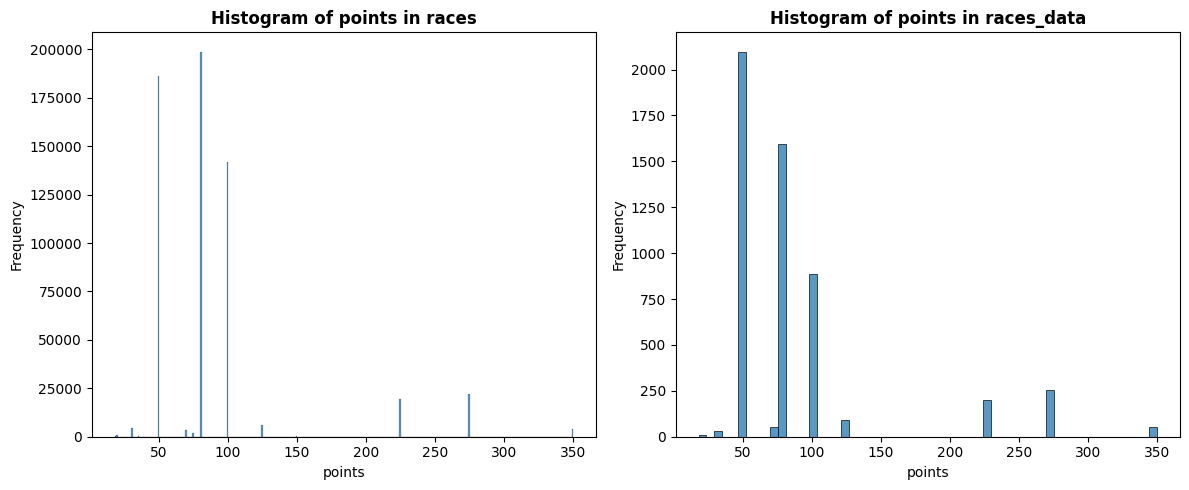

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Histogram for races (redundant rows present)
sbn.histplot(races['points'], ax=axes[0])
axes[0].set_title(f'Histogram of points in races', fontweight='bold')
axes[0].set_xlabel('points')
axes[0].set_ylabel('Frequency')

# Histogram for races_data (redudant rows removed)
sbn.histplot(races_data['points'], ax=axes[1])
axes[1].set_title(f'Histogram of points in races_data', fontweight='bold')
axes[1].set_xlabel('points')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

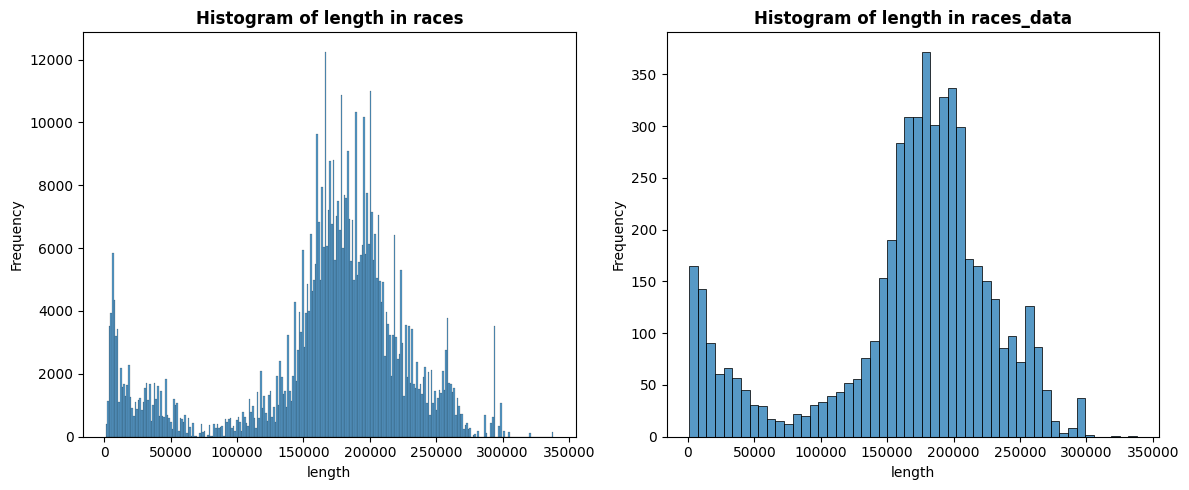

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Histogram for races (redundant rows present)
sbn.histplot(races['length'], ax=axes[0])
axes[0].set_title(f'Histogram of length in races', fontweight='bold')
axes[0].set_xlabel('length')
axes[0].set_ylabel('Frequency')

# Histogram for races_data (redudant rows removed)
sbn.histplot(races_data['length'], ax=axes[1])
axes[1].set_title(f'Histogram of length in races_data', fontweight='bold')
axes[1].set_xlabel('length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

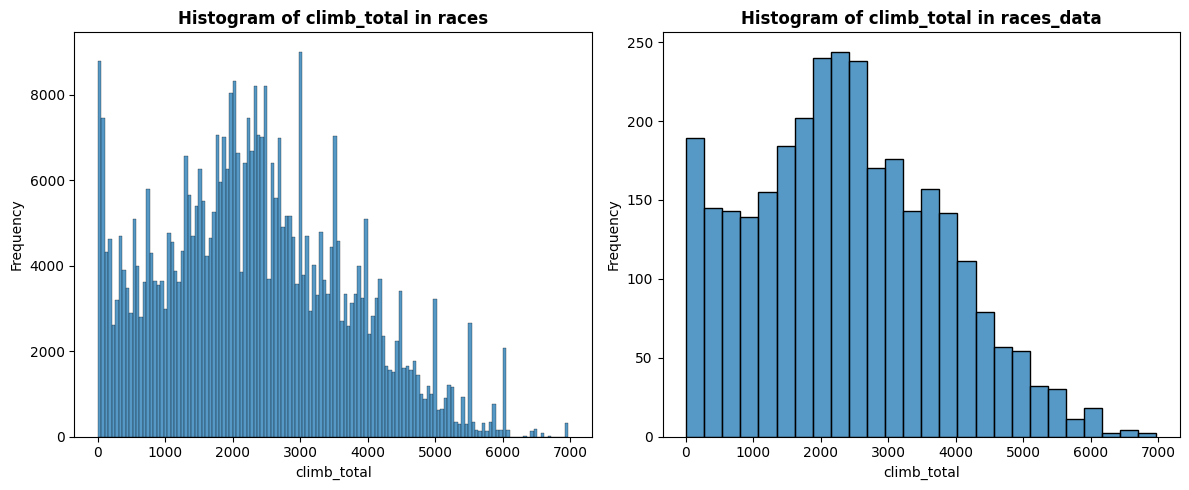

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Histogram for races (redundant rows present)
sbn.histplot(races['climb_total'], ax=axes[0])
axes[0].set_title(f'Histogram of climb_total in races', fontweight='bold')
axes[0].set_xlabel('climb_total')
axes[0].set_ylabel('Frequency')

# Histogram for races_data (redudant rows removed)
sbn.histplot(races_data['climb_total'], ax=axes[1])
axes[1].set_title(f'Histogram of climb_total in races_data', fontweight='bold')
axes[1].set_xlabel('climb_total')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Therefore, to avoid producing misleading distributions and statistics for attributes that are specific to individual races, we chose to split the dataset into two separate tables. This separation minimizes the bias introduced by repeated entries for the same event, ensuring that race-specific attributes are analyzed accurately without distortion from redundancy.

In this step, we add the date column to races_data because it is specified in the project documentation as the race start date. However, it is important to note that in reality, this date column varies for each placement, meaning it is not actually tied to the race event itself but rather to an individual cyclist entry.
<br>
Further analyses concerning the relationship between date and delta (a metric for timing differences) will be conducted in the placements notebook. 

In [11]:
# Define columns that belong to the placements (cyclist-specific) and races (event-specific)
cyclist_races_columns = ['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date']
races_columns = [col for col in races.columns if col not in cyclist_races_columns]

# Extract placements_data to contain cyclist-specific information for each event and add 'external key'
placements = races[cyclist_races_columns + ['_url']].reset_index(drop=True)

# Extract races to contain only unique events with event-specific information
races = races.drop_duplicates(subset=races_columns)[races_columns + ['date']].reset_index(drop=True)

In this dataset, we will focus our analysis on races, which contains unique event-specific information for each race.

## Check null for each column

As we can see below, there are some features with an high percentage of null values, in particular the _average\_temperature_ feature, which has the 95% of values set to null. A column with a such number of null values provides very few useful information for the analysis. So, keeping such a column could introduce noise and may negatively impact the use of clustering or prediction algorithms.

In [12]:
stats_on_missing_values(races)

,Feature,Null_counter,Perc_of_null_(%)
0,_url,0,0.0
1,name,0,0.0
2,points,4,0.1
3,uci_points,3682,69.7
4,length,0,0.0
5,climb_total,2214,41.9
6,profile,2408,45.6
7,startlist_quality,0,0.0
8,average_temperature,5076,96.1
9,is_tarmac,0,0.0


## Check distribution of null values across rows

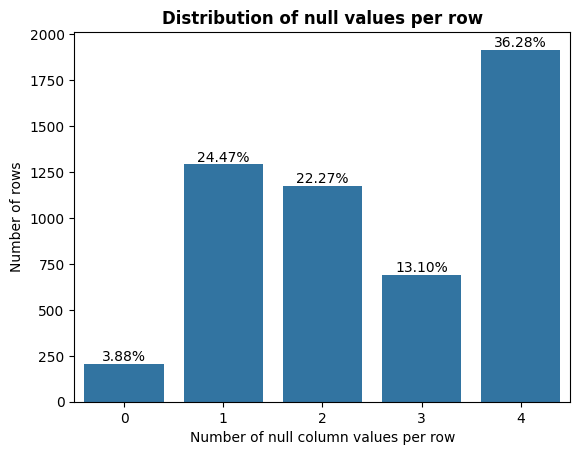

In [13]:
# compute the number of null values for each row
races['null_count'] = races.isnull().sum(axis=1)

ax=sbn.countplot(x='null_count', data=races, legend=False)
total = len(races['null_count'])

#% over the bars
for p in ax.patches:
    height = p.get_height()  #height of the bar
    percentage = 100 * height / total  #determine the %
    ax.text(
        p.get_x() + p.get_width() / 2,  #Position the text in the middle of the bar
        height,  #Position on the bar end
        f'{percentage:.2f}%', 
        ha='center',           # Horizontal alignment
        va='bottom'            # Vertical alignment
    )

plt.title('Distribution of null values per row', fontweight='bold')
plt.xlabel('Number of null column values per row')
plt.ylabel('Number of rows')

plt.show()
plt.close()

We show the rows with the highest number of null values

In [14]:
max_null_count = races['null_count'].max()
rows_with_max_null = races[races['null_count'] == max_null_count]
print("Rows with the highest number of null values:")
display(rows_with_max_null)
races.drop(columns=['null_count'], inplace=True)

Rows with the highest number of null values:


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,null_count
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50.0,NaN,8100.0,NaN,NaN,804,NaN,True,False,False,1999-06-17 00:10:12,4
8,volta-a-catalunya/1981/stage-2b,Volta Ciclista a Catalunya,50.0,NaN,30000.0,NaN,NaN,388,NaN,True,False,False,1981-09-05 00:44:24,4
9,paris-nice/1994/stage-8b,Paris - Nice,50.0,NaN,12500.0,NaN,NaN,900,NaN,True,False,False,1994-03-13 00:22:06,4
10,tirreno-adriatico/1984/stage-1,Tirreno-Adriatico,50.0,NaN,189000.0,NaN,NaN,541,NaN,True,False,False,1984-03-09 05:14:53,4
11,dauphine/1991/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,222000.0,NaN,NaN,830,NaN,True,False,False,1991-06-05 05:41:27,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5262,tour-de-romandie/2002/stage-2,Tour de Romandie,50.0,NaN,172800.0,NaN,NaN,535,NaN,True,False,False,2002-05-02 03:45:11,4
5265,paris-nice/1990/stage-5,Paris - Nice,50.0,NaN,164000.0,NaN,NaN,995,NaN,True,False,False,1990-03-09 04:03:24,4
5267,paris-nice/2000/stage-3,Paris - Nice,50.0,NaN,178000.0,NaN,NaN,880,NaN,True,False,False,2000-03-08 04:28:35,4
5273,tirreno-adriatico/1993/stage-3,Tirreno-Adriatico,50.0,NaN,184000.0,NaN,NaN,568,NaN,True,False,False,1993-03-12 05:14:05,4


A great number of rows (about 36%) have 4 missing fields, typically _uci points_, _climb total_, _profile_, _avg temperature_.

# Data distribution

Custom procedure that produces some basic statistics on a single feature of the dataset.

In [15]:
from distribution_utility import stats_and_distribution, show_stats, calculate_outlier_bounds
from cast_utility import cast_column_to_Int64, cast_column_to_string

## _url

The _\_url_ is a categorical feature of type object. We can convert it into pandas string.

In [16]:
cast_column_to_string(races, '_url')

Column casted from object to string


In [17]:
show_stats(races, "_url", attr_type='categorical')

Description of attribute '_url':


count                            5281
unique                           5281
top       tour-de-france/1978/stage-6
freq                                1
Name: _url, dtype: object


Unique values:
['tour-de-france/1978/stage-6' 'vuelta-a-espana/2016/stage-14'
 'tour-de-france/2019/stage-21' ... 'paris-nice/1976/stage-2'
 'volta-a-catalunya/2016/stage-7' 'giro-d-italia/2010/stage-1']

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
tour-de-france/1978/stage-6      1
vuelta-a-espana/1990/stage-19    1
paris-nice/1972/stage-2          1
tour-de-romandie/2021/stage-4    1
tour-de-france/1986/prologue     1
Name: _url, dtype: int64


The __url_ feature can be considered as an identifier of the race event. The url is in the form _eventName/year/stagename_.<br>
The fact that there are many rows with URLs starting with _Tour de France_ or _Giro d'Italia_ is related to the importance of these two events in the cycling world. These two races typically have many participants and **are composed of more than one stage**. <br>
Initially we found that the bar chart was illegible due to the high number of unique values in the URLs. To overcome this, we used the first part of the URLs to identify the event_name associated with each event. This truncation reduced complexity and greatly improved the clarity of our visualisation. We created a more interpretable bar chart of the distribution of events by event_name, making the data both informative and accessible.

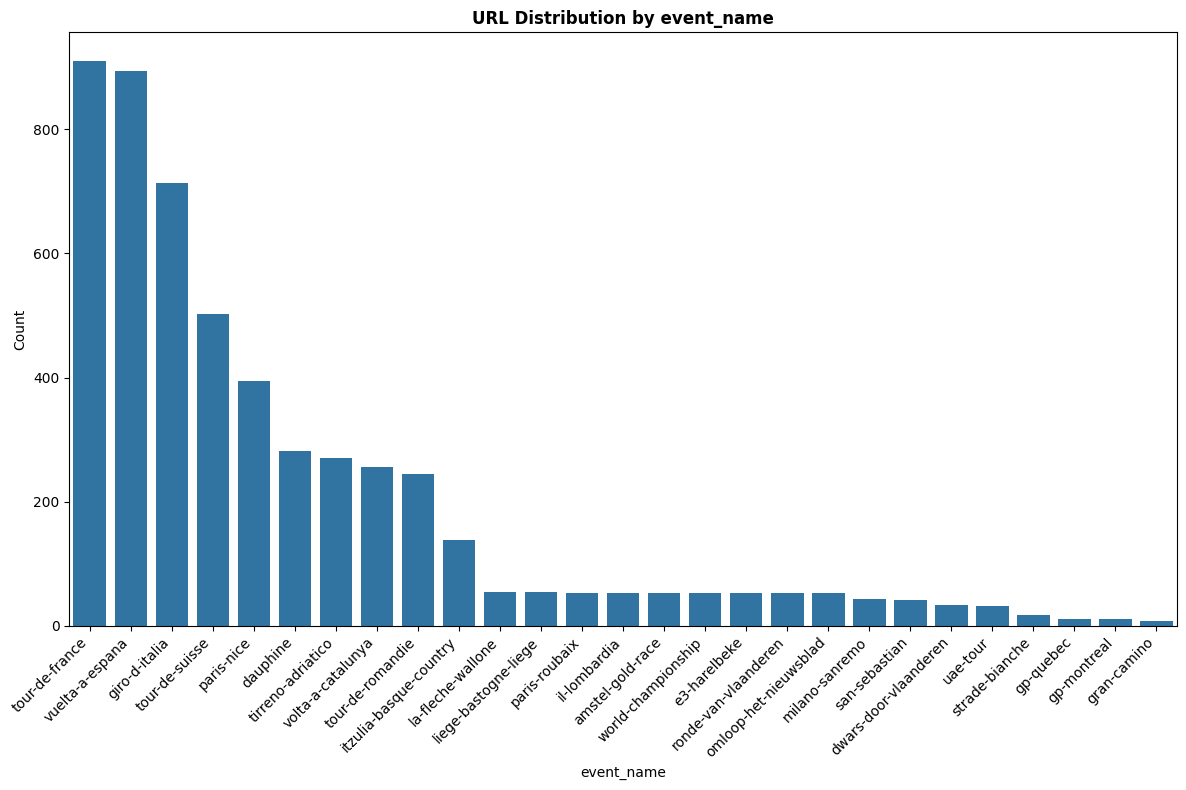

In [18]:
event_names = races['_url'].apply(lambda x: x.split('/')[0])
events_counts = event_names.value_counts()

plt.figure(figsize=(12,8))
sbn.barplot(x= events_counts.index, y= events_counts.values)
plt.title('URL Distribution by event_name', fontweight='bold')
plt.xlabel('event_name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them horizontally
plt.tight_layout()  # Adjust layout to ensure everything fits without overlapping
plt.show()

## name

The _name_ is a categorical feature of type object. Convert it from object to pandas string

In [19]:
cast_column_to_string(races, 'name')

Column casted from object to string


Description of attribute 'name':


count               5281
unique                61
top       Tour de France
freq                 911
Name: name, dtype: object


Unique values:
['Tour de France' 'Vuelta a España' 'Volta Ciclista a Catalunya'
 'Paris - Nice' 'Tirreno-Adriatico' 'Critérium du Dauphiné Libéré'
 'Critérium du Dauphiné' 'Ronde van Vlaanderen / Tour des Flandres'
 'Milano-Sanremo' 'Tour de Suisse' "Giro d'Italia" 'Gran Camiño'
 'Tour de Romandie' 'Volta a Catalunya' 'La Vuelta ciclista a España'
 'La Flèche Wallonne' 'E3-Prijs Harelbeke' 'Vuelta al País Vasco'
 'Vuelta Ciclista al País Vasco' 'Liège - Bastogne - Liège'
 'Paris-Roubaix' 'UAE Tour' 'World Championships ME - Road Race'
 'Amstel Gold Race' 'Dwars door België / À travers la Belgique'
 'Itzulia Basque Country' 'World Championships - Road Race'
 'Criterium du Dauphiné Libére' 'Omloop Het Volk'
 'Clasica Ciclista San Sebastian' 'Paris - Roubaix' 'Strade Bianche'
 'Giro di Lombardia' 'Criterium du Dauphiné' 'O Gran Camiño'
 'Grand Prix Cycliste de Quebec' 'Grand Prix Cycliste de Montréal'
 'Ronde van Vlaanderen - Tour des Flandres ME'
 'Dwars door Vlaanderen - A travers la F

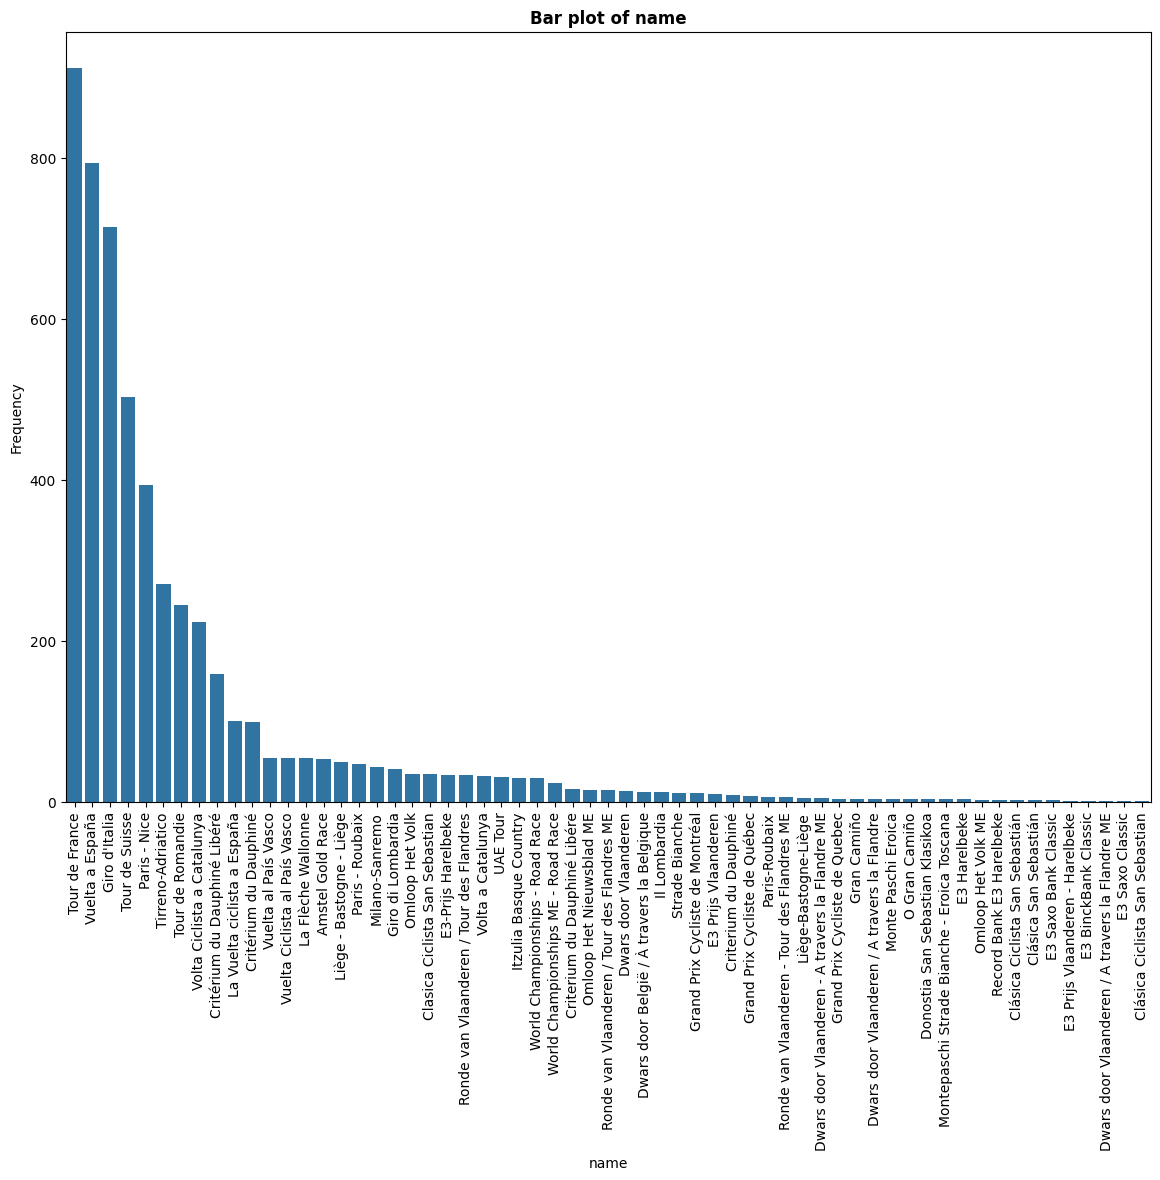

In [20]:
stats_and_distribution(races, 'name', attr_type='categorical')

There are no missing values and, as expected and already explained, the most common values are the names of the more prestigious races. <br>
We encountered a high number of unique values in the 'name' attribute compared to the truncated _url attribute. This can be due to the presence of articles or additional letters, causing variations of the name even for the same race event. 

## points

_Points_ and _uci points_ are numeric continuous attributes. Their type can be cast to int since there are no decimals.

In [21]:
cast_column_to_Int64(races, 'points')

Column casted from float64 to Int64


Description of attribute 'points':


count       5277.0
mean     89.465795
std      61.414859
min           18.0
25%           50.0
50%           80.0
75%          100.0
max          350.0
Name: points, dtype: Float64


Unique values:
<IntegerArray>
[100, 80, 50, 275, 20, 225, 125, 350, 75, 70, 30, 150, 35, <NA>, 18]
Length: 15, dtype: Int64

Null values: 4 over 5281 records - (0.08%)

Top 5 most frequent values:
50     2098
80     1596
100     886
275     256
225     201
Name: points, dtype: Int64


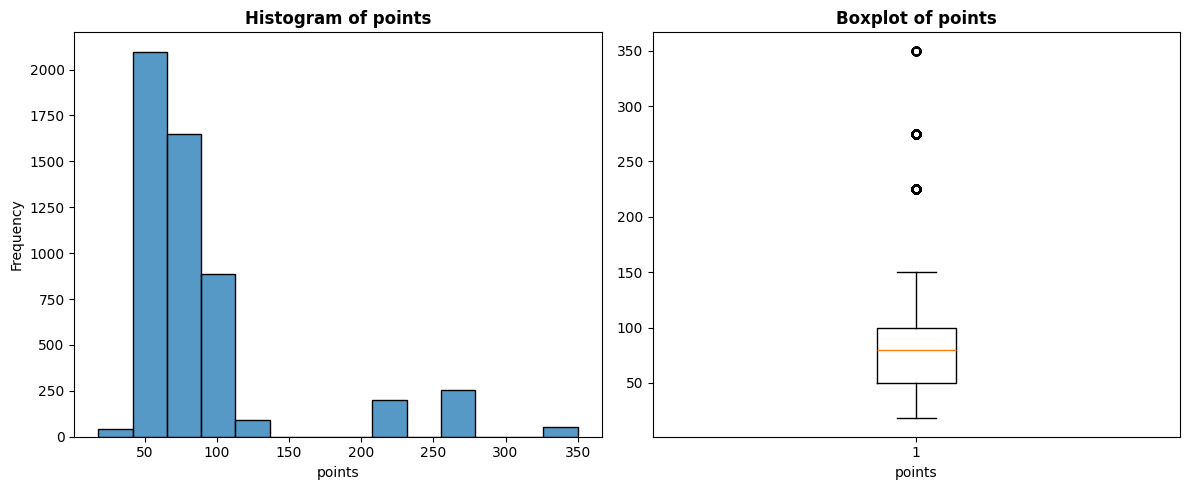

Outliers in points: [225, 275, 350]


In [22]:
stats_and_distribution(races, "points", attr_type='numerical')

The histogram and the boxplot of points shows a distribution primarily between 50 and 100, with outliers extending up to around 350. <br>
Many races have scores in this range, and those beyond the 95th quantile are notably longer. In fact, all these races have lengths above the 85th percentile of the overall lengths.

In [23]:
quantile_95_points = races['points'].quantile(0.95)
quantile_85_length = races['length'].quantile(0.85)
races[races['points'] > quantile_95_points]['length'].min() > quantile_85_length

True

The relationship we noted between points and length doesn't hold when it comes to climb_total. Specifically, the minimum climb_total for races with points above the 95th quantile does not exceed the 85th percentile of climb_total values. This discrepancy indicates that while longer races tend to have higher points, the same cannot be inferred for climb_total.

In [24]:
quantile_95_points = races['points'].quantile(0.95)
quantile_85_climb_total = races['climb_total'].quantile(0.85)
races[races['points'] > quantile_95_points]['climb_total'].min() > quantile_85_climb_total

False

Moreover, all high-scoring races are of the 'result' type. We found that there are no races with high points that are not classified as 'result'. 

In [25]:
quantile_95_points = races['points'].quantile(0.95)
races[(races['points'] > quantile_95_points) & ~races['_url'].str.contains('result')].size == 0

True

## uci_points

In [26]:
cast_column_to_Int64(races, 'uci_points')

Column casted from float64 to Int64


Description of attribute 'uci_points':


count        1599.0
mean      82.097561
std      113.896141
min             6.0
25%            16.0
50%            60.0
75%           100.0
max           800.0
Name: uci_points, dtype: Float64


Unique values:
<IntegerArray>
[<NA>,  100,  120,   50,   60,    6,   14,   16,  500,   20,   40,  210,  400,
  300,  800,  180,  200,  600,   80,   10,  402]
Length: 21, dtype: Int64

Null values: 3682 over 5281 records - (69.72%)

Top 5 most frequent values:
100    288
6      285
60     271
16     229
120    123
Name: uci_points, dtype: Int64


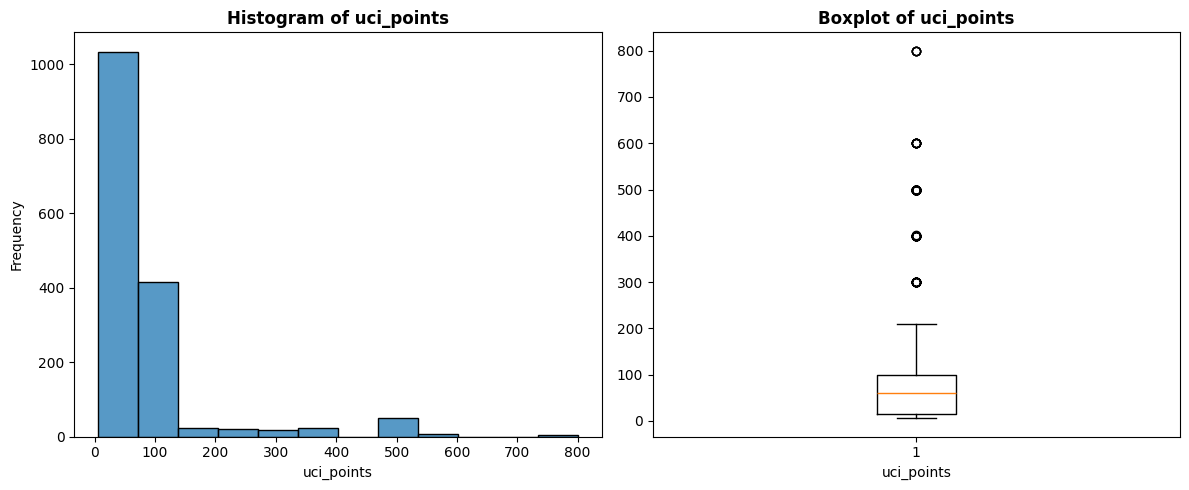

Outliers in uci_points: [800, 300, 400, 402, 500, 600]


In [27]:
stats_and_distribution(races, "uci_points", attr_type='numerical')

## length

The _length_ is a numeric continuous attribute representing the length of the race event. The values in the column may have some decimal places. Since the feature represents the length of the race in meters, and there are decimals in irrelevant positions (e.g. 32200.000000000003638), we decide to round to the unit (meters), so we cast to int.

In [28]:
# We use 'Int64' to correctly manage also NaN values
print(races['length'].dtype)

pd.set_option('display.float_format', '{:.15f}'.format)
decimal_values = races['length'] % 1 != 0
values_with_decimals = races['length'][decimal_values]

print(f"\nSome of the values with several decimals places:\n{values_with_decimals}\n")

rounded_length = races['length'].round(1)
rounded_length_int = rounded_length.astype('Int64')
# print(rounded_length_int)
try:
    res = np.all(rounded_length_int == races['length'].round(1))
    print("Castable")
    if res:
        races['length'] = races['length'].round().astype('Int64')
        print(races['length'].dtype)
        decimal_values = races['length'] % 1 != 0
        values_with_decimals = races['length'][decimal_values]
        print(values_with_decimals)

        pd.reset_option('display.float_format')
except TypeError:
    print("Not castable!")

float64

Some of the values with several decimals places:
103     32200.000000000003638
224    258600.000000000029104
542    256600.000000000029104
1451    16190.000000000001819
1568   259100.000000000029104
1941   257600.000000000029104
2047   259100.000000000029104
2091   261600.000000000029104
2780    32200.000000000003638
4390   259350.000000000029104
4587   258100.000000000029104
Name: length, dtype: float64

Castable
Int64
Series([], Name: length, dtype: Int64)


Description of attribute 'length':


count           5281.0
mean     165685.627722
std       67889.860679
min             1000.0
25%           149000.0
50%           179000.0
75%           205500.0
max           338000.0
Name: length, dtype: Float64


Unique values:
<IntegerArray>
[162000, 196000, 128000,   8100, 192900, 117500,  52000, 154800,  30000,
  12500,
 ...
  98800,  97500, 205300, 142700,  82600, 320500, 224500, 301000, 184200,
 136400]
Length: 1280, dtype: Int64

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
200000    46
190000    42
175000    41
202000    40
180000    39
Name: length, dtype: Int64


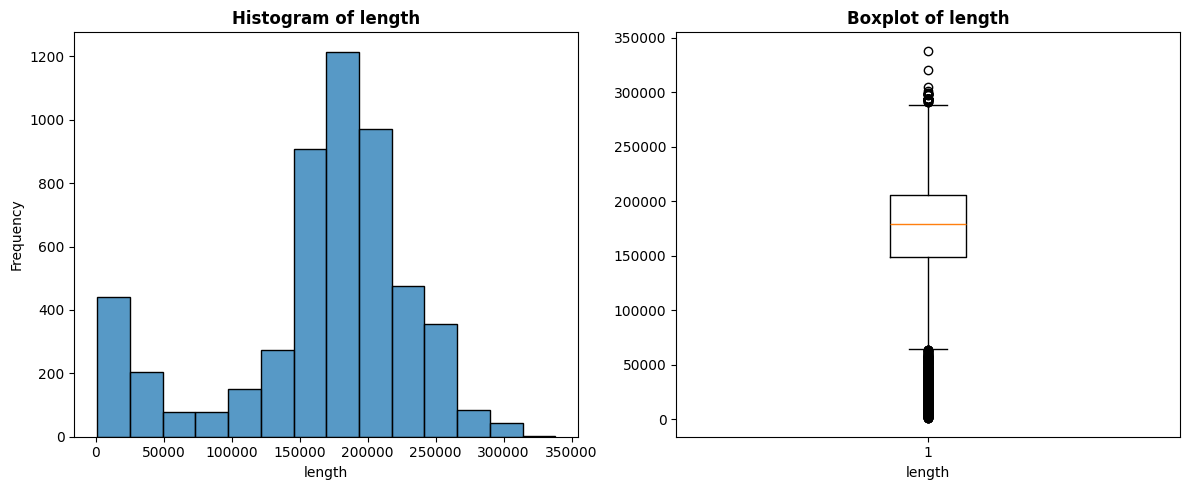

Outliers in length: [4100, 59400, 8200, 12300, 63500, 16400, 20500, 24600, 36900, 41000, 297000, 53300, 6200, 61500, 14400, 18500, 26700, 30800, 338000, 34900, 39000, 4200, 6250, 59500, 12400, 16500, 20600, 24700, 37000, 293000, 6300, 57500, 10400, 14500, 18600, 26800, 30900, 35000, 291000, 55500, 4300, 8400, 12500, 33000, 37100, 41200, 53500, 6400, 22800, 26900, 31000, 8500, 12600, 18750, 49500, 6500, 18800, 27000, 31100, 47500, 4500, 8600, 12700, 16800, 25000, 29100, 45500, 6600, 16850, 18900, 39400, 2550, 4600, 8700, 64000, 12800, 25100, 41500, 6700, 10800, 62000, 19000, 27200, 39500, 4700, 8800, 60000, 12900, 17000, 25200, 29300, 33400, 37500, 41600, 45700, 6800, 58000, 10900, 15000, 23200, 6820, 4800, 8900, 13000, 17100, 33500, 54000, 4850, 6900, 11000, 15100, 19200, 15110, 31500, 43800, 52000, 4900, 9000, 13100, 29500, 50000, 2900, 7000, 15200, 23400, 25450, 27500, 35700, 39800, 48000, 5000, 9100, 60300, 13200, 17300, 25500, 29600, 33700, 37800, 46000, 3000, 7100, 11200, 15300, 1

In [29]:
stats_and_distribution(races, "length", attr_type='numerical')

We identified that many of the very short races, particularly those considered outliers, are prologues. This trend highlights how prologues tend to be significantly shorter compared to other race stages, providing a distinct category within our dataset.

In [30]:
lower_bound = calculate_outlier_bounds(races, 'length')['lower']
races[races['length'] < lower_bound]['_url'].str.split('/').str[2].value_counts().head()

prologue    181
stage-1      51
stage-5      35
stage-8      31
stage-4      31
Name: _url, dtype: int64

Furthermore, while there are some long races not classified as 'result,' a significant number of these long races are indeed of the 'result' type. This underscores the trend that many single-stage races tend to be longer in length.

In [31]:
upper_bound = calculate_outlier_bounds(races, 'length')['upper']
races[races['length'] > upper_bound]['_url'].str.split('/').str[2].value_counts().head()

result      39
stage-4      2
stage-20     1
stage-9      1
stage-21     1
Name: _url, dtype: int64

## climb_total

_Climb total_ is a numeric continuous attribute representing the number of metres climbed during the race event. Its type can be cast to int since there are no decimals.

In [32]:
cast_column_to_Int64(races, 'climb_total')

Column casted from float64 to Int64


Description of attribute 'climb_total':


count         3067.0
mean     2375.650473
std      1394.390513
min              2.0
25%           1333.0
50%           2307.0
75%           3358.0
max           6974.0
Name: climb_total, dtype: Float64


Unique values:
<IntegerArray>
[1101, 5575,  781, <NA>, 3743, 3817, 1351, 2008, 3828, 3867,
 ...
 2190, 1410,  477, 3765, 3562, 4156, 2359,  713, 1441,   60]
Length: 2118, dtype: Int64

Null values: 2214 over 5281 records - (41.92%)

Top 5 most frequent values:
2500    36
3500    36
4000    29
3000    24
4500    21
Name: climb_total, dtype: Int64


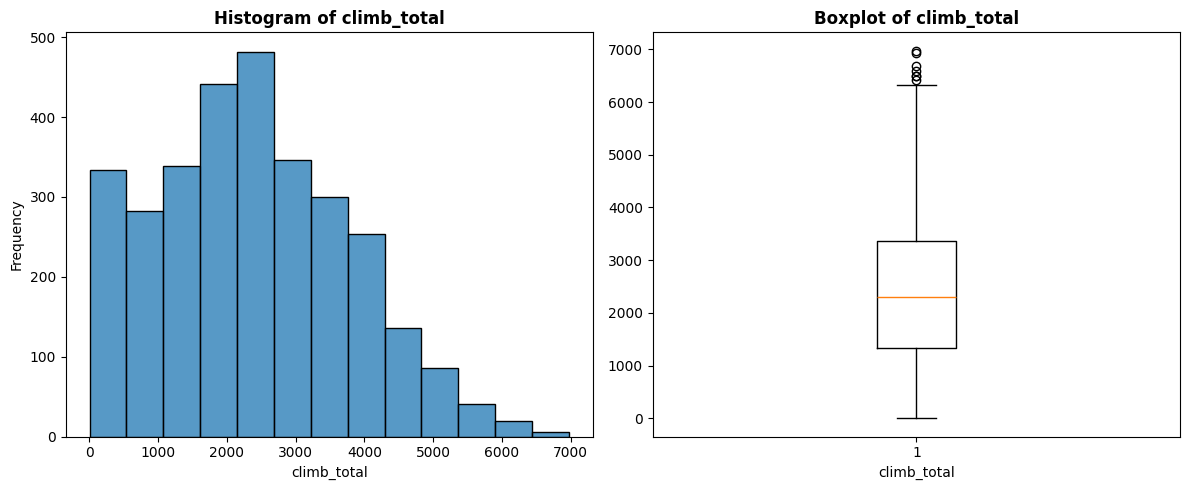

Outliers in climb_total: [6500, 6425, 6939, 6589, 6974, 6687]


In [33]:
stats_and_distribution(races, "climb_total", attr_type='numerical')

The histogram of climb_total shows a positive skew, indicating most races have fewer climbing kilometers, while a few have significantly more. The boxplot reveals that the median climb_total is around 3000 meters, with some outliers exceeding 6000 meters. These outliers represent exceptionally challenging races.

## profile

The _profile_ feature is a categorical ordinal attribute. It has a range from 1 to 5 and it represents the difficulty of that race event. Its type can be cast to int since there are no decimals. <br>

In [34]:
cast_column_to_Int64(races, 'profile')

Column casted from float64 to Int64


Description of attribute 'profile':


count     2873
unique       5
top          2
freq       867
Name: profile, dtype: int64


Unique values:
[1 5 <NA> 3 2 4]

Null values: 2408 over 5281 records - (45.60%)

Top 5 most frequent values:
2    867
1    817
5    575
3    327
4    287
Name: profile, dtype: int64


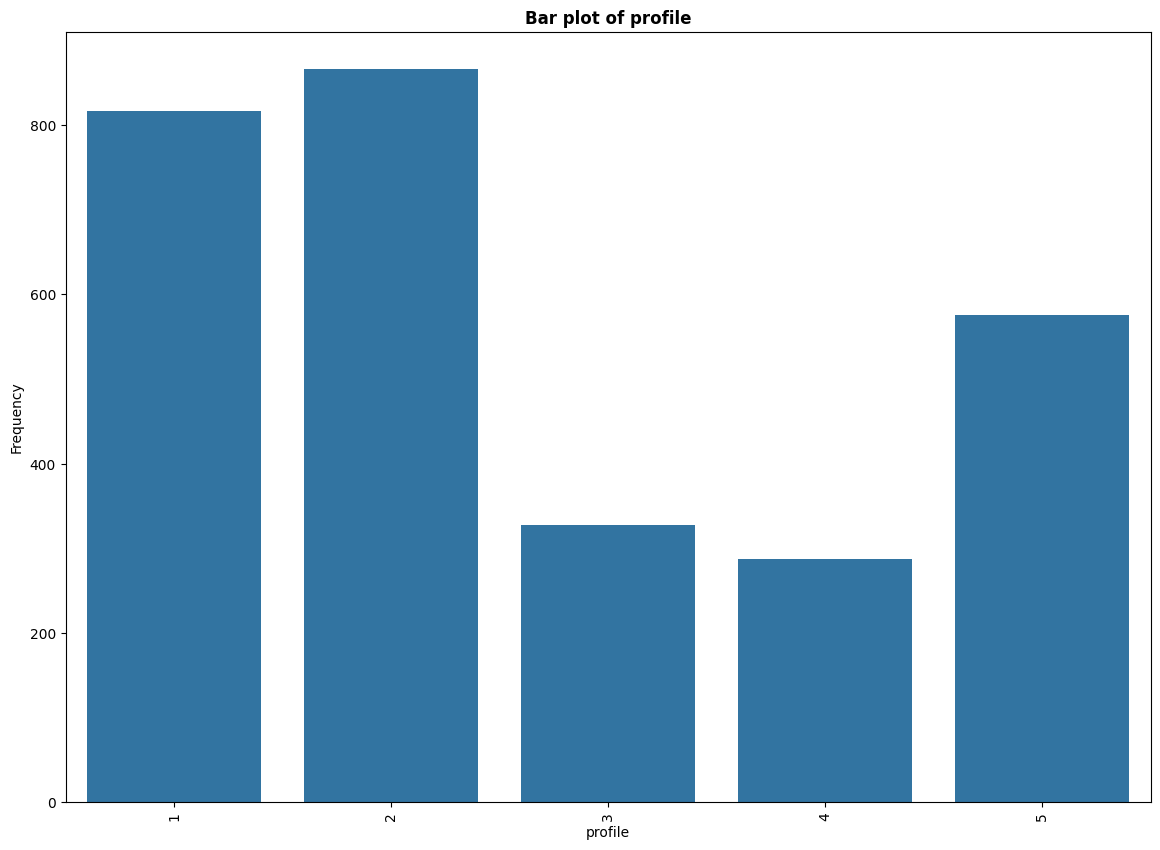

In [35]:
stats_and_distribution(races, "profile", attr_type='categorical')

## startlist_quality

The _startlist quality_ feature is a numeric continuous attribute. It's a number that summarizes the overall competitiviness of the cyclists participating to a race event. It is already of type int

In [36]:
print(races['startlist_quality'].dtype)
races['startlist_quality'].value_counts()

int64


971     60
838     50
1872    45
1812    45
920     43
        ..
1594     1
304      1
1120     1
594      1
1149     1
Name: startlist_quality, Length: 697, dtype: int64

Description of attribute 'startlist_quality':


count    5281.000000
mean      988.701572
std       380.450977
min       115.000000
25%       747.000000
50%       917.000000
75%      1165.000000
max      2047.000000
Name: startlist_quality, dtype: float64


Unique values:
[1241  821 1699  804 1551  899  659  388  900  541  830  789  602  817
 1400 1161 1040  896  791  819  670  225  520 1057  809  828  722  747
  714  815  376  621  760  798  933 1994 1437 1362  884 1150  971  881
 1112 1175  891  878  400  936  692  727 1002  928 1196 1489  687  585
  835  673 1328  885  502  861  982  923 1036 1690  925  989 1109 1084
  803  792  548  668 1713 1520 1959  883  859 2047 1024  533 1269  751
 1202  570 1703 1416  251 1158 1139  657 1048  521 1034 1099  880 1029
  627  340  767  737 1220  824  369 1255 1019  995 1059 1342  968  676
 1381  705  680  779 1123 1020 1632 1251 1470  708  892  523  590  604
  781  614 1309  951 1812  877 1758  843 1041 1646  935  660  961 1238
 1496  765  494 1933  956 1849 1136  393  882  597  874  908  888  530
 1089  446  838  373 1872  638  794  932 1331  377  719 1121 1042 1165
 1105 1535 1492  732  866  920  917 1584  653  906  551  611  772  852
  607 1177  389  873  966  775  790 1090  302  478  952 1176 

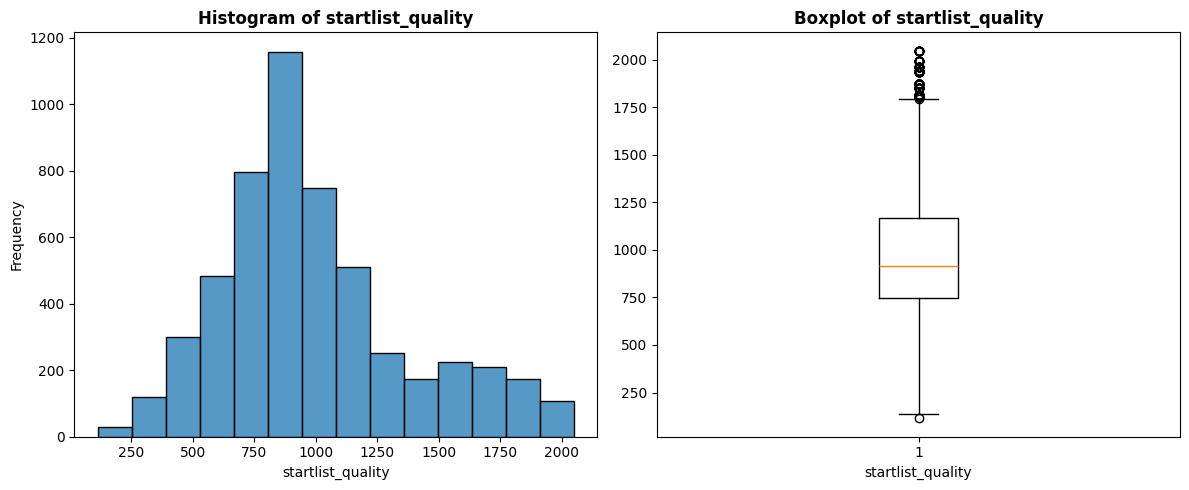

Outliers in startlist_quality: [1794, 1959, 1994, 1804, 1933, 1871, 1872, 115, 1812, 1941, 1849, 2047]


In [37]:
stats_and_distribution(races, "startlist_quality", attr_type='numerical')

The analysis of the distribution of startlist quality in cycling races shows a pronounced positive skew: most events have medium to low competitiveness, while a select few prestigious races attract the top athletes, creating a right tail in the distribution. The analysis confirms that only a narrow elite of races can draw the strongest champions in the cycling world, highlighting a clear distinction between high-prestige events and the rest of the calendar. 

## average_temperature
The _average temperature_ feature is a numeric continous attribute. It describes the average temperature recorded during that race. Its type can be cast to int since there are no decimals.

In [38]:
# We use 'Int64' to correctly manage also NaN values
cast_column_to_Int64(races, 'average_temperature')

Column casted from float64 to Int64


Description of attribute 'average_temperature':


count       205.0
mean     21.62439
std      5.959042
min          10.0
25%          17.0
50%          22.0
75%          26.0
max          36.0
Name: average_temperature, dtype: Float64


Unique values:
<IntegerArray>
[<NA>,   24,   22,   13,   10,   19,   29,   20,   11,   25,   15,   23,   31,
   21,   27,   32,   16,   14,   26,   30,   28,   18,   17,   34,   12,   35,
   36,   33]
Length: 28, dtype: Int64

Null values: 5076 over 5281 records - (96.12%)

Top 5 most frequent values:
23    15
20    14
22    14
24    12
25    12
Name: average_temperature, dtype: Int64


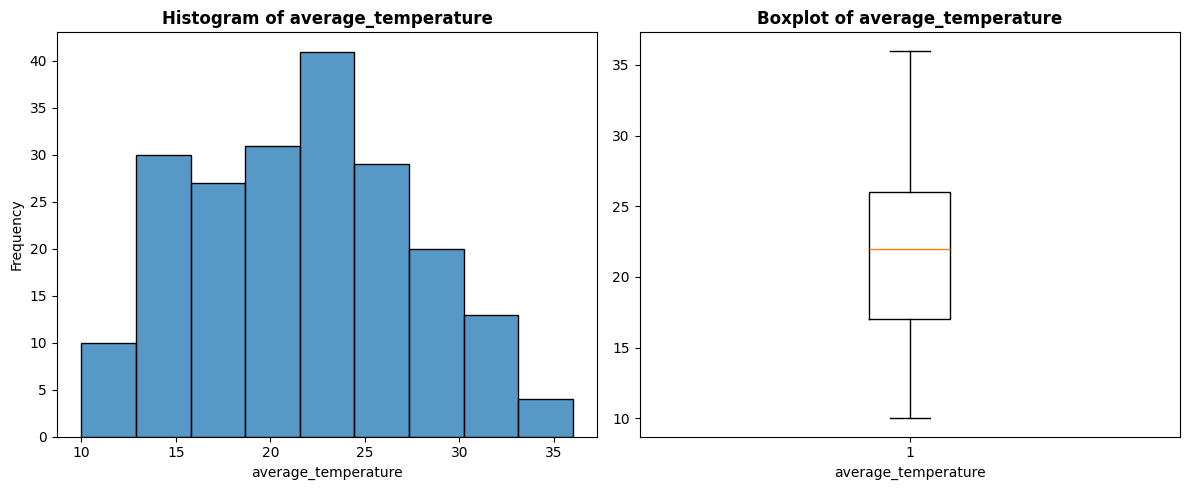

Outliers in average_temperature: []


In [39]:
stats_and_distribution(races, "average_temperature", attr_type='numerical')

## is_tarmac

Description of attribute 'is_tarmac':


count     5281
unique       2
top       True
freq      4645
Name: is_tarmac, dtype: object


Unique values:
[ True False]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
True     4645
False     636
Name: is_tarmac, dtype: int64


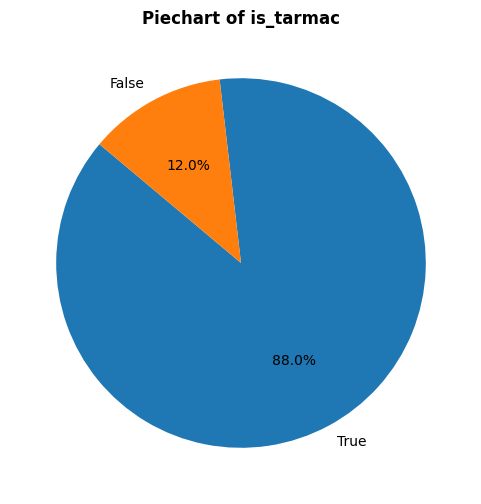

In [40]:
stats_and_distribution(races, 'is_tarmac', attr_type='binary')

## is_cobbled
This feature has only False values, so it doesn't provide any information to the analysis. For the moment, we convert it from bool to int. 

Description of attribute 'is_cobbled':


count      5281
unique        1
top       False
freq       5281
Name: is_cobbled, dtype: object


Unique values:
[False]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
False    5281
Name: is_cobbled, dtype: int64


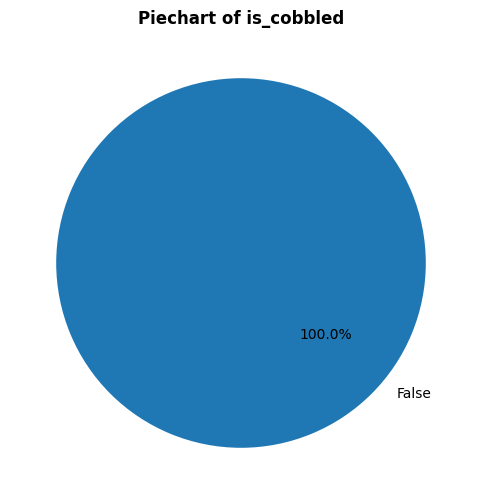

In [41]:
stats_and_distribution(races, 'is_cobbled', attr_type='binary')

## is_gravel
This feature has only False values, so it doesn't provide any information to the analysis.

Description of attribute 'is_gravel':


count      5281
unique        1
top       False
freq       5281
Name: is_gravel, dtype: object


Unique values:
[False]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
False    5281
Name: is_gravel, dtype: int64


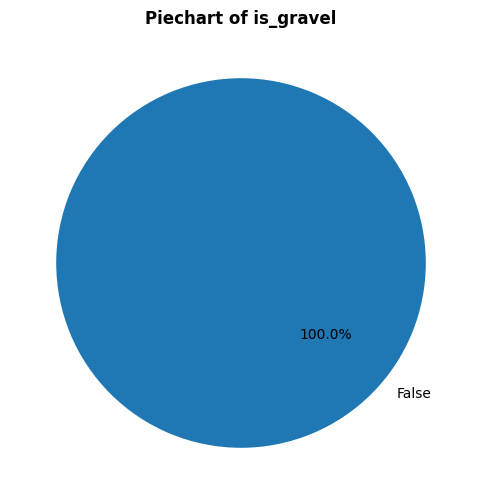

In [42]:
stats_and_distribution(races, 'is_gravel', attr_type='binary')

## date
We convert date into datetime format, but since we are not interested in time information, we set it to midnight.

The _date_ feature is numeric continuos attribute. It represents the timestamp of the race start. For our purposes the time is irrelevant, so the column can be cast to 'date'. <br>

In [43]:
races['date'] = pd.to_datetime(races['date']).dt.floor('d')
print(races['date'].dtype)

datetime64[ns]


In [44]:
show_stats(races, 'date')

Description of attribute 'date':


c:\Users\simon\Desktop\Data Mining\Progetto\RepoCondivisa\dm-2024-project\notebook\task_1_2\../../src\distribution_utility.py:20: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(column.describe())


count                    5281
unique                   4708
top       1996-03-17 00:00:00
freq                        4
first     1970-02-28 00:00:00
last      2023-07-29 00:00:00
Name: date, dtype: object


Unique values:
['1978-07-05T00:00:00.000000000' '2016-09-03T00:00:00.000000000'
 '2019-07-28T00:00:00.000000000' ... '1976-03-09T00:00:00.000000000'
 '2016-03-27T00:00:00.000000000' '2010-05-08T00:00:00.000000000']

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
1996-03-17    4
1988-03-12    3
1993-05-08    3
1984-03-14    3
1984-03-11    3
Name: date, dtype: int64


We notice that we have race events held in the same day.

To present a meaningful plot, we've decided to group the data into 2-year intervals and create a bar plot on this group. This manual binning technique provides a clearer visual representation of the event counts over time, making it easier to identify trends and patterns.

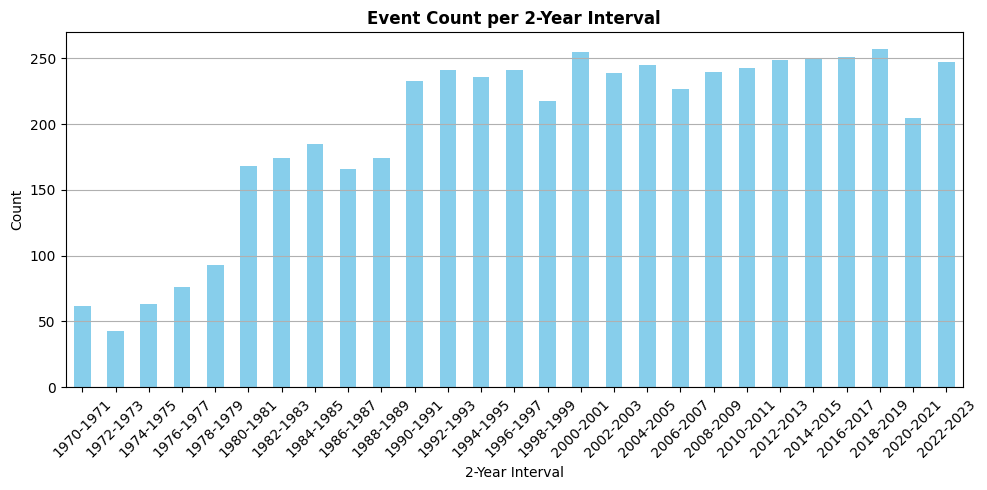

In [45]:
# Group by 2-year intervals
races['year'] = races['date'].dt.year
races['year_group'] = (races['year'] // 2) * 2  # Round the year to the nearest multiple of 2

# Count occurrences for each 2-year interval
year_counts = races.groupby('year_group').size()

# Create labels for 2-year intervals
year_labels = [f"{year}-{year+1}" for year in year_counts.index]

# Create the bar plot
plt.figure(figsize=(10, 5))
year_counts.plot(kind="bar", color='skyblue')
plt.title('Event Count per 2-Year Interval', fontweight='bold')
plt.xlabel('2-Year Interval')
plt.ylabel('Count')
plt.xticks(ticks=range(len(year_labels)), labels=year_labels, rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
races.drop(columns = ['year_group', 'year'], inplace=True)

1970-1977 is the period with the lowest number of races. From 1988 to 2023, the number of races in each two-year period does not show any significant variability (more or less  constant between 200-250). In 2020-2021 we can observe a decrease in the number of races, probably due to the covid restrictions at the beginning of 2020.

# Data quality

### Name

As we can see by sorting all the unique values of the column name, there are some race names that may refer to the same race event. In fact there are only few differences in those name such as the presence of:
- accents ['Clásica Ciclista San Sebastian' vs 'Clásica Ciclista San Sebastián]
- separating characters (- or /) ['Liège - Bastogne - Liège' vs 'Liège-Bastogne-Liège']
- articles ['La Vuelta ciclista a España' vs 'Vuelta a España]
- translations ['Ronde van Vlaanderen' vs 'Tour des Flandres]
Actually this is not a problem for our analysis. The starting part of the _url feature, which is the name of the race event, is correctly formatted for all of these "mismatch" situations.

In [46]:
unique_names=races['name'].unique()
sorted(unique_names)

['Amstel Gold Race',
 'Clasica Ciclista San Sebastian',
 'Clásica Ciclista San Sebastian',
 'Clásica Ciclista San Sebastián',
 'Clásica San Sebastián',
 'Criterium du Dauphiné',
 'Criterium du Dauphiné Libére',
 'Critérium du Dauphiné',
 'Critérium du Dauphiné Libéré',
 'Donostia San Sebastian Klasikoa',
 'Dwars door België / À travers la Belgique',
 'Dwars door Vlaanderen',
 'Dwars door Vlaanderen - A travers la Flandre ME',
 'Dwars door Vlaanderen / A travers la Flandre',
 'Dwars door Vlaanderen / A travers la Flandre ME',
 'E3 BinckBank Classic',
 'E3 Harelbeke',
 'E3 Prijs Vlaanderen',
 'E3 Prijs Vlaanderen - Harelbeke',
 'E3 Saxo Bank Classic',
 'E3 Saxo Classic',
 'E3-Prijs Harelbeke',
 "Giro d'Italia",
 'Giro di Lombardia',
 'Gran Camiño',
 'Grand Prix Cycliste de Montréal',
 'Grand Prix Cycliste de Quebec',
 'Grand Prix Cycliste de Québec',
 'Il Lombardia',
 'Itzulia Basque Country',
 'La Flèche Wallonne',
 'La Vuelta ciclista a España',
 'Liège - Bastogne - Liège',
 'Liège-Bas

**TODO** Vedere correlazione con presenza di ME e maggiore startlist quality

### is_gravel, is_tarmac, is_cobbled


As we can see in the code cell below, the columns _is gravel_ and _is cobbled_ contain only False values. It means that they provide no information because all the records in the dataset have the same value for these attributes (Entropy=0).
It seems that the 3 attributes representing the race surfaces were obtained by binarizing an original single categorical column. 


In [47]:
races[(races['is_gravel'] == True) | (races['is_cobbled'] == True)].shape[0]

0

Regarding the _is tarmac_ feature, most of the records have a true value.

In [48]:
prob_is_tarmac = races['is_tarmac'].value_counts(normalize=True) 
#normalize=True to get the proportion and not the absolute frequency
print(prob_is_tarmac)
prob_is_tarmac=prob_is_tarmac.to_numpy()

True     0.879568
False    0.120432
Name: is_tarmac, dtype: float64


There are also records where all the 3 features have a false value. This may be due to a missing value in the original categorical column before the binarization.

In [49]:
races[(races['is_gravel'] == False) & (races['is_tarmac'] == False) & (races['is_cobbled'] == False)]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date
13,ronde-van-vlaanderen/1980/result,Ronde van Vlaanderen / Tour des Flandres,275,<NA>,265000,<NA>,<NA>,602,<NA>,False,False,False,1980-03-30
15,milano-sanremo/2004/result,Milano-Sanremo,275,<NA>,294000,<NA>,<NA>,1400,<NA>,False,False,False,2004-03-20
48,la-fleche-wallone/2015/result,La Flèche Wallonne,225,<NA>,205500,3030,3,1112,<NA>,False,False,False,2015-04-22
52,e3-harelbeke/2002/result,E3-Prijs Harelbeke,125,<NA>,209000,<NA>,2,400,<NA>,False,False,False,2002-03-30
69,liege-bastogne-liege/1999/result,Liège - Bastogne - Liège,275,<NA>,264000,<NA>,<NA>,1328,<NA>,False,False,False,1999-04-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5244,milano-sanremo/1996/result,Milano-Sanremo,275,<NA>,294000,<NA>,<NA>,1580,<NA>,False,False,False,1996-03-23
5248,amstel-gold-race/2013/result,Amstel Gold Race,225,<NA>,251800,3500,2,1149,<NA>,False,False,False,2013-04-14
5268,san-sebastian/2017/result,Clásica Ciclista San Sebastian,225,400,231000,4156,2,800,<NA>,False,False,False,2017-07-29
5269,gp-quebec/2010/result,Grand Prix Cycliste de Quebec,225,<NA>,189000,<NA>,3,824,<NA>,False,False,False,2010-09-10


We notice that the only column with both True and False values is '_is_tarmac_'. However, 90.9% of the rows have a True value and only 9.1% have a False value, so this column also provides little information, as we can reasonably assume that every professional cycling competition has a part of the race on asphalt.

### Average Temperature

This feature has 95% of missing values, so it's very difficult to reconstruct these values in a meaningful way. It could be reasonable to exclude that feature from the further analysis.

In [50]:
per=(((len(races[races['average_temperature'].isna()]))*100)/len(races))
print(f"Missing values: {per:.2f}%")

Missing values: 96.12%


### Points e UCI_points


The UCI score in cycling is a ranking system used by the Union Cycliste Internationale (UCI) to determine the top cyclists and teams in the world. It is based on a points system where cyclists earn points for their performance in various races throughout the season. The UCI score is used to determine the World Champion, the UCI World Ranking, and the qualification for major cycling events like the Tour de France.

Actually in this dataset the attributes 'uci_points' and 'points' are strictly related to a race event and not, as we would expect, to the placement of a cyclist in a particular race event. The fact that a race has two scores creates a sort of ambiguity.

In [51]:
races[races['points'].isna()].shape[0]

4

In [52]:
races[races['uci_points'].isna()].shape[0]

3682

As we can see the feature uci_points has a lot of missing values (>50% of the number of records). In particular all the races held before the 2001 do not have not this information. This may be due the introduction of this scoring system in the early 2000s. 

In [53]:
cutoff_date = pd.to_datetime("2001-1-1")
filtered=races[races['date'] <= cutoff_date]
filtered=filtered.sort_values(by='date', ascending=True)
filtered=filtered[filtered['uci_points'].notna()]
#check if there are missing values before 1/1/2001
filtered.shape[0]==0

True

Given the fact that, as shown in the correlation analysis section, 'uci_points' and 'points' are highly correlated and 'uci_points' have many missing values, we can decide to drop these feature and maintain only 'points'.

### startlist_quality

In [54]:
races['startlist_quality'].describe()

count    5281.000000
mean      988.701572
std       380.450977
min       115.000000
25%       747.000000
50%       917.000000
75%      1165.000000
max      2047.000000
Name: startlist_quality, dtype: float64

In [55]:
races['startlist_quality'].value_counts()

971     60
838     50
1872    45
1812    45
920     43
        ..
1594     1
304      1
1120     1
594      1
1149     1
Name: startlist_quality, Length: 697, dtype: int64

check values distribution

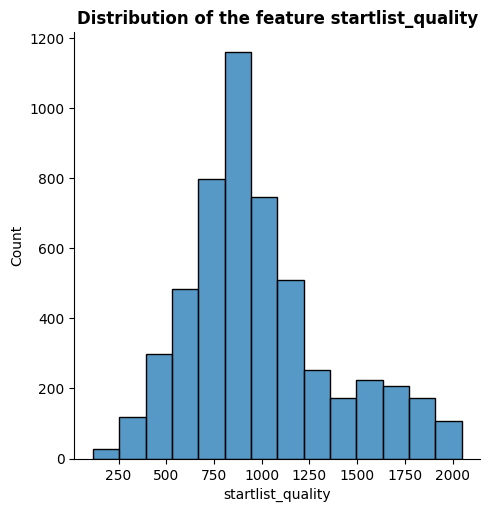

In [56]:
sbn.displot(races, x= "startlist_quality", kind="hist", row_order="desc", bins='sturges')
plt.title("Distribution of the feature startlist_quality", fontweight='bold')
plt.show()

**Checking whether each _url matches the same startlist_quality value** <br>
We obtain this checking is correct, so it proves that the startlist_quality is a feature linked to the specific race and not to the cyclists.

In [57]:
# number of unique startlist_quality values for each unique _url
unique_startlists_for_urls = races.groupby('_url')['startlist_quality'].nunique()
inconsistent_urls = unique_startlists_for_urls[unique_startlists_for_urls > 1]
if inconsistent_urls.empty:
    print("For each unique _url there is a specific startlist_quality")
else:
    print("For each unique _url there are different startlist_quality values")

For each unique _url there is a specific startlist_quality


### profile
Checking whether each _url matches the same profile value.

This checking shows that a specific profile correspond to a specific race. The same race doesn't correspond to different profiles.

In [58]:
# number of unique startlist_quality values for each unique _url
unique_profiles_for_urls = races.groupby('_url')['profile'].nunique()
inconsistent_urls = unique_profiles_for_urls[unique_profiles_for_urls > 1]
if inconsistent_urls.empty:
    print("For each unique _url there is a specific profile")
else:
    print("For each unique _url there are different profile values")

For each unique _url there is a specific profile


There is no inconsistent information regarding a specific race event. An example of an anomalous situation is the case where two rows referring to the same race event have different values for a race-specific attribute such as length, avg_temperature, profile...

In [59]:
# count the frequence of each distinct _url
values_count = races['_url'].value_counts()
# if a race has a frequency > 1 then this race may represent an inconsistency between the race's attributes
inconsistent_urls = values_count[values_count > 1]
len(inconsistent_urls)

0

### Length


As we can see in the notebook section on data distribution, the distribution of the feature _length_ has an anomalous shape. It seems to be a Gaussian distribution, but with a strange peak for very low values of length. This could be due, for example, the use of a different unit of measure to represent the distance (Km vs Metres).
Perhaps some races have a length expressed in Kilometres rather than Metres, since the maximum for this column is 338000, the mean is 166776.180584 and the minimum is 1000.

Let's try to identify the race events with a short length value. We initially set a threshold of 10000.

In [60]:
temp = races[races['length'] <= 10000]
temp['_url'].value_counts()

volta-a-catalunya/1999/prologue    1
tour-de-suisse/2007/prologue       1
paris-nice/2008/prologue           1
tour-de-suisse/1982/prologue       1
paris-nice/2000/prologue           1
                                  ..
vuelta-a-espana/1987/prologue      1
tour-de-suisse/1976/prologue       1
paris-nice/2006/prologue           1
paris-nice/2013/stage-7            1
giro-d-italia/2010/stage-1         1
Name: _url, Length: 249, dtype: Int64

We notice that there are some race events with a length < 10000 and most of them have a suffix of the url matching "prologue" or "stage-1". In fact, by searching information on the project domain, we discovered that the prologue is a short *individual time trial* that takes place at the start of a multi stage race. The prologue has typicalle a maximum length of 8 Km (according to UCI regulations) and it's used to determine the initial time gaps between the riders in the race stages. <br>

Some multistage races have not a prologue but a *stage1* with a short (but >8Km) length or a massive start (not individual).

In [61]:
#Statistics for prologue races
unique_subset = races[races['_url'].str.contains("prologue")][['_url', 'length']].drop_duplicates(subset=['_url'])
unique_subset.describe()

,length
count,181.0
mean,5745.414365
std,1913.273655
min,1000.0
25%,4100.0
50%,5700.0
75%,7000.0
max,10200.0


# Correlation analysis

## Correlation matrix

### Pearson method

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\4070097787.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  pearson_matrix = races[numeric_columns].corr(method = "pearson")


,points,uci_points,startlist_quality,length,climb_total,average_temperature
points,1.000000,0.886923,0.150258,0.443933,0.148629,-0.145383
uci_points,0.886923,1.000000,-0.027519,0.308246,0.112018,-0.207581
startlist_quality,0.150258,-0.027519,1.000000,0.075864,0.040131,0.352969
length,0.443933,0.308246,0.075864,1.000000,0.530568,-0.078542
climb_total,0.148629,0.112018,0.040131,0.530568,1.000000,-0.133245
average_temperature,-0.145383,-0.207581,0.352969,-0.078542,-0.133245,1.000000


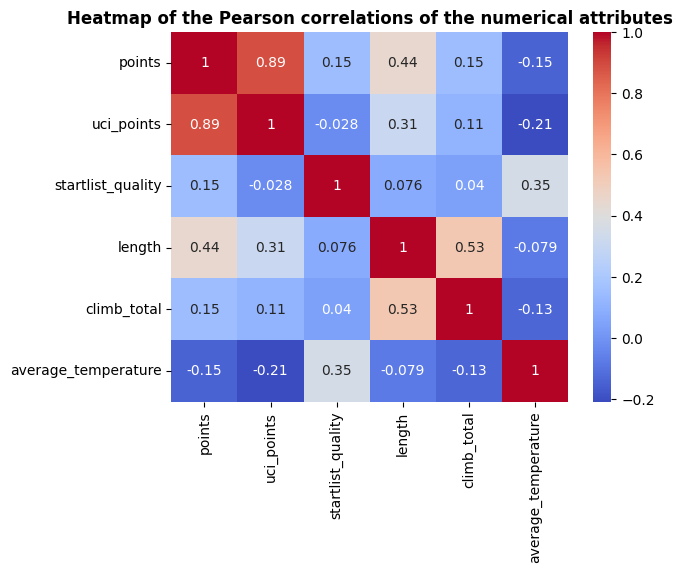

In [62]:
numeric_columns = ['points', 'uci_points', 'startlist_quality', 
                   'length', 'climb_total', 'average_temperature', 'date']
pearson_matrix = races[numeric_columns].corr(method = "pearson")
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap of the Pearson correlations of the numerical attributes", fontweight='bold')
plt.show()
plt.close()

Here follow some observations based on the values of the correlation matrix:

- Points and UCI Points (0.89): This is the strongest linear relationship in the dataset. It highlights a direct, proportional increase between race points and UCI points. Races that award more points to participants also tend to assign higher UCI points, which is logical since both metrics measure aspects of race prestige and performance.

- Length and Climb Total (0.53): A moderately strong linear relationship exists between the total race length and the total climbing involved. Longer races generally involve more elevation gain, reflecting the nature of race design.

- UCI Points and Date (0.42): A moderate positive linear relationship between UCI points and the race date indicates that more recent races tend to award slightly higher UCI points.

- Points and Length (0.44): A weak to moderate positive linear relationship indicates that longer races tend to award more points. This suggests that race length partially influences how points are distributed.

### Kendall method

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\1429873257.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  kendall_matrix = races[ord_and_num_columns].corr(method = "kendall")


,profile,points,uci_points,startlist_quality,length,climb_total,average_temperature
profile,1.000000,-0.103855,-0.010730,-0.076665,0.006156,0.572520,-0.013459
points,-0.103855,1.000000,0.514667,0.346395,0.327285,0.062379,0.118070
uci_points,-0.010730,0.514667,1.000000,-0.008093,0.130646,0.058834,0.040138
startlist_quality,-0.076665,0.346395,-0.008093,1.000000,0.047565,0.009008,0.205643
length,0.006156,0.327285,0.130646,0.047565,1.000000,0.296914,-0.095148
climb_total,0.572520,0.062379,0.058834,0.009008,0.296914,1.000000,-0.080778
average_temperature,-0.013459,0.118070,0.040138,0.205643,-0.095148,-0.080778,1.000000


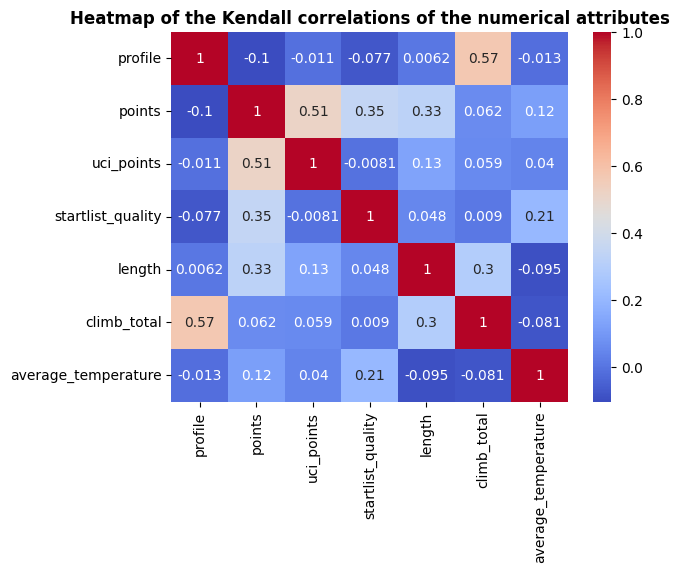

In [63]:
numeric_columns = ['points', 'uci_points', 'startlist_quality', 
                   'length', 'climb_total', 'average_temperature', 'date']
ord_and_num_columns = ['profile'] + numeric_columns
kendall_matrix = races[ord_and_num_columns].corr(method = "kendall")
display(kendall_matrix)
sbn.heatmap(kendall_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap of the Kendall correlations of the numerical attributes", fontweight='bold')
plt.show()
plt.close()

- Profile and Climb Total (0.57): Moderate rank-based association where more challenging profiles are associated with greater total elevation gain. This is expected, as mountainous or hilly profiles naturally involve more climbing.

- Points and UCI Points (0.51): Moderate rank-based relationship indicating that races awarding more points also rank higher in UCI points. These metrics are closely related to race prestige.

- Date and UCI Points (0.52): Newer races tend to rank higher in UCI points, reflecting possible scoring system changes or the increasing significance of recent events.

### Spearman method

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\3032049231.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  spearman_matrix = races[ord_and_num_columns].corr(method = "spearman")


,profile,points,uci_points,startlist_quality,length,climb_total,average_temperature
profile,1.000000,-0.129869,-0.012463,-0.105513,0.017010,0.719651,-0.024093
points,-0.129869,1.000000,0.570804,0.433169,0.419894,0.080448,0.146430
uci_points,-0.012463,0.570804,1.000000,-0.014302,0.181733,0.082228,0.049054
startlist_quality,-0.105513,0.433169,-0.014302,1.000000,0.071058,0.012182,0.290636
length,0.017010,0.419894,0.181733,0.071058,1.000000,0.423762,-0.135045
climb_total,0.719651,0.080448,0.082228,0.012182,0.423762,1.000000,-0.121198
average_temperature,-0.024093,0.146430,0.049054,0.290636,-0.135045,-0.121198,1.000000


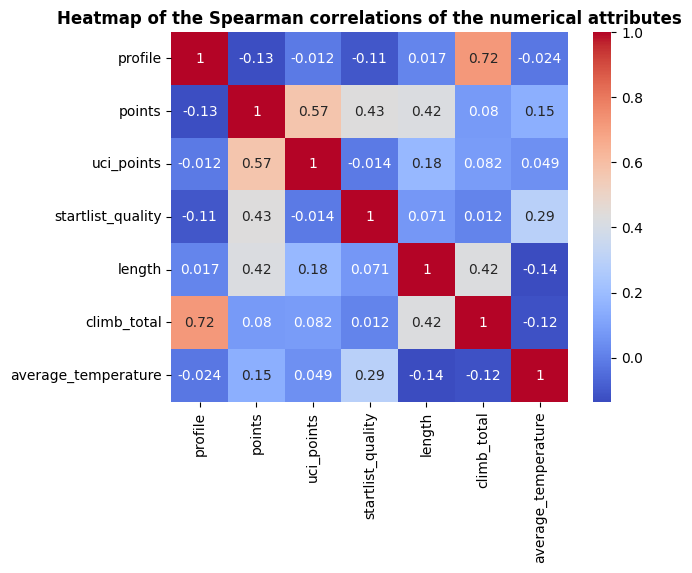

In [64]:
numeric_columns = ['points', 'uci_points', 'startlist_quality', 
                   'length', 'climb_total', 'average_temperature', 'date']
ord_and_num_columns = ['profile'] + numeric_columns
spearman_matrix = races[ord_and_num_columns].corr(method = "spearman")
display(spearman_matrix)
sbn.heatmap(spearman_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap of the Spearman correlations of the numerical attributes", fontweight='bold')
plt.show()
plt.close()

- Profile and Climb Total (0.72): There is a strong positive monotonic correlation between profile and climb_total. This is expected, as a hilly or mountainous profile naturally involves greater elevation gain.

- UCI Points and Date (0.73): A strong positive monotonic correlation shows that UCI Points tend to increase with more recent dates.

- Points and UCI Points (0.57): A moderate positive monotonic correlation suggests that races awarding more points also tend to have higher UCI Points. This aligns with expectations, as both metrics are measures of race prestige.

- Points and Startlist Quality (0.43): A moderate positive monotonic correlation indicates that races with higher points awarded tend to have higher startlist quality. This aligns with expectetions since more prestigious races with higher points attract stronger fields of participants.

- Points and Length (0.42): A moderate positive monotonic correlation suggests that longer races tend to award more points. This seems to suggest us that longer races are typically more prestigious, warranting higher points.

## Scatter plot

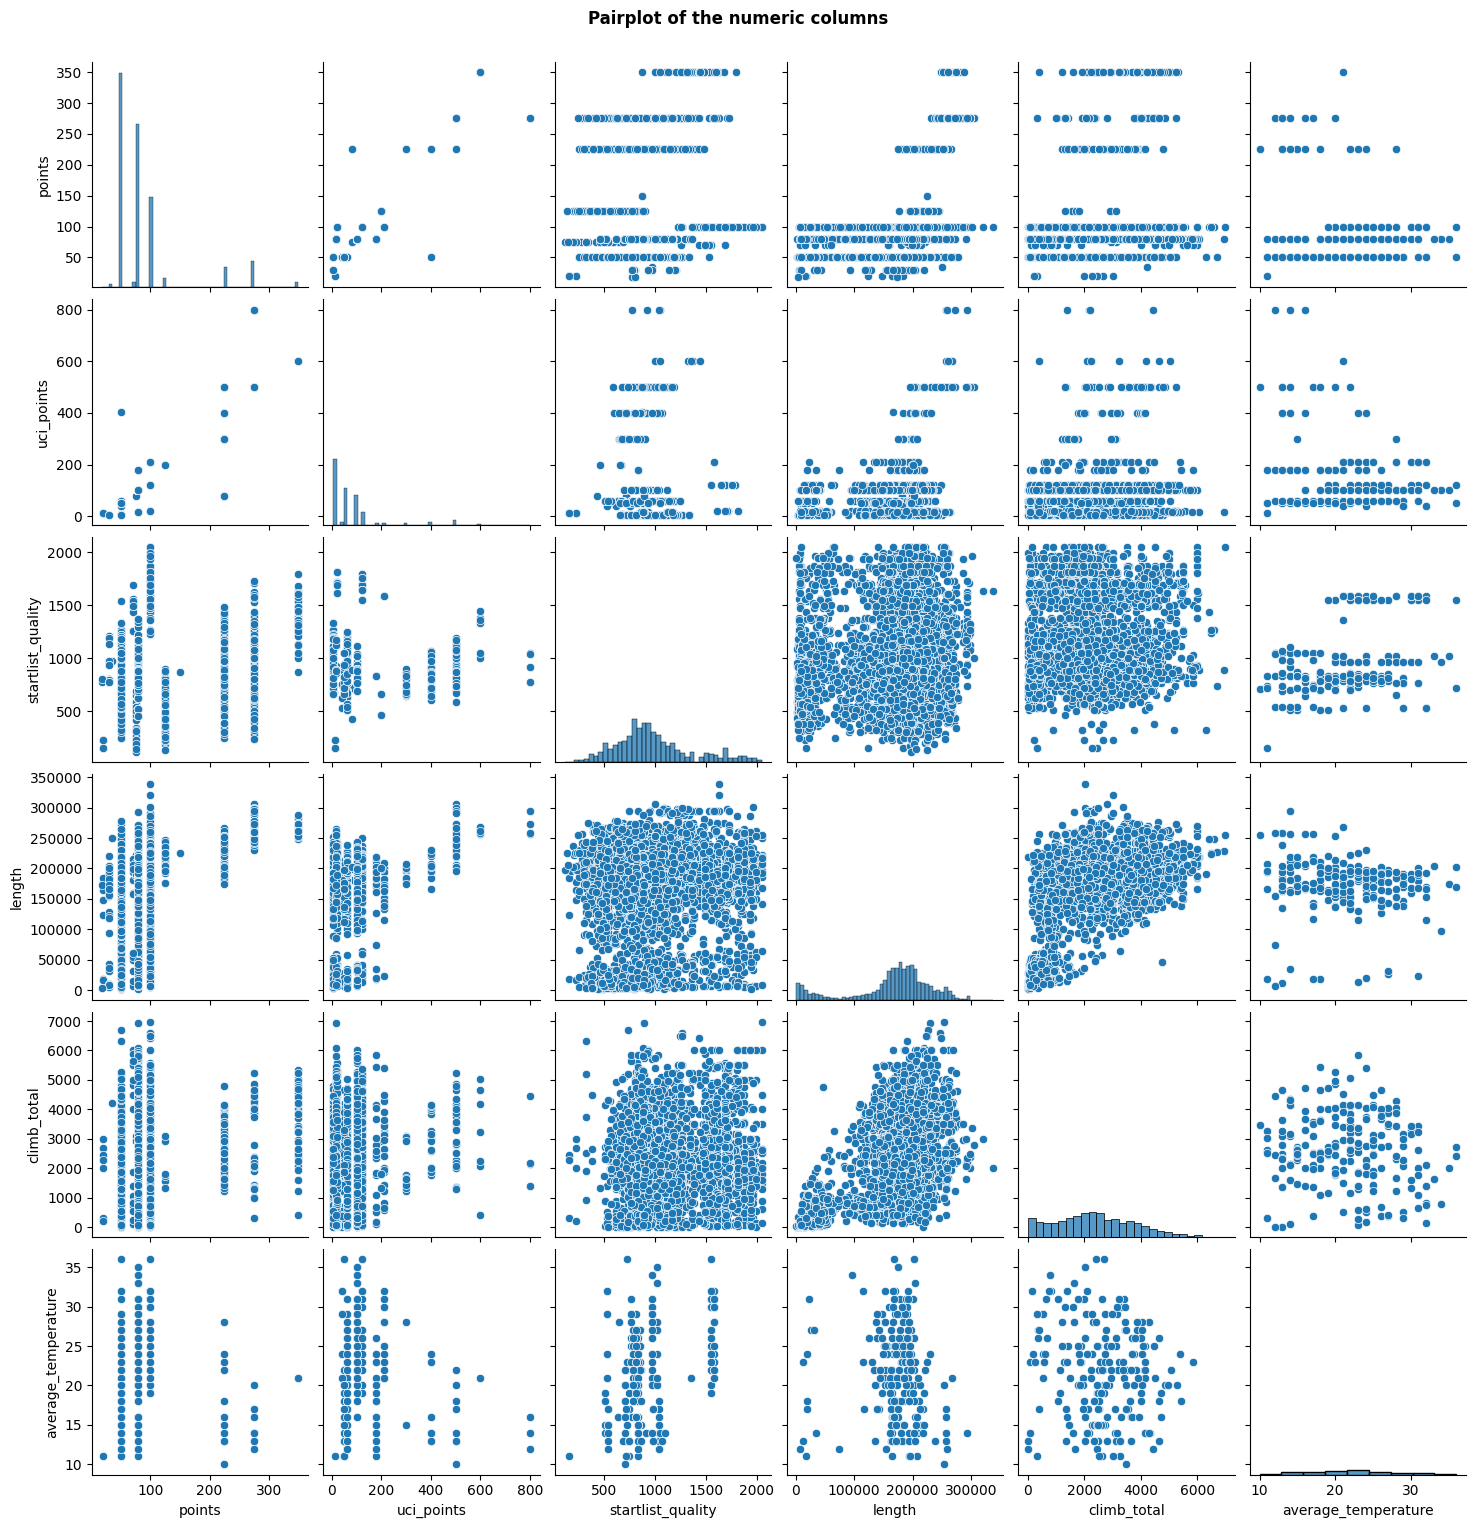

In [65]:
pairplot = sbn.pairplot(races[numeric_columns])
pairplot.fig.suptitle("Pairplot of the numeric columns", fontweight='bold', y=1.02)
plt.show()
plt.close()

A strong and logical relationship is between points and UCI points (Pearson: 0.89, Spearman: 0.57, Kendall: 0.51). These two variables are closely related since races with more points are typically more prestigious and align with higher UCI points. The scatterplot shows a clear linear trend, confirming the tight connection between these metrics, which is expected given their shared purpose of quantifying race importance and outcomes.

Another strong relationships is observed is profile and climb_total. Across all correlation methods, there is a consistent and significant connection between these two variables. This makes intuitive sense: as the profile of a race becomes more challenging (e.g., hilly or mountainous), the total elevation gain naturally increases.

# New features
## Climb/length ratio
We decided to introduce the climb/length ratio feature to see if there was still a good/higher correlation with the 'profile' ordinal feature of the race. Note that this is a feature related to the race event itself and not to the cyclist's placement in the race.

In [66]:
races['climb/length'] = races['climb_total'] / races['length']

Description of attribute 'climb/length':


count      3067.0
mean     0.014813
std      0.009059
min      0.000069
25%      0.008803
50%      0.013438
75%      0.018845
max      0.103261
Name: climb/length, dtype: Float64


Unique values:
<FloatingArray>
[0.006796296296296296,  0.02844387755102041,         0.0061015625,
                 <NA>,  0.01940383618455158, 0.032485106382978725,
  0.02598076923076923, 0.012971576227390182, 0.028397626112759644,
  0.02052547770700637,
 ...
  0.01946448087431694, 0.017991341991341992, 0.002329479768786127,
  0.01583221476510067, 0.011720430107526882, 0.006309734513274336,
 0.019238095238095238, 0.009736486486486487,  0.01378299120234604,
 0.007142857142857143]
Length: 3016, dtype: Float64

Null values: 2214 over 5281 records - (41.92%)

Top 5 most frequent values:
0.01244     3
0.02957     3
0.0075      3
0.012376    3
0.015437    2
Name: climb/length, dtype: Int64


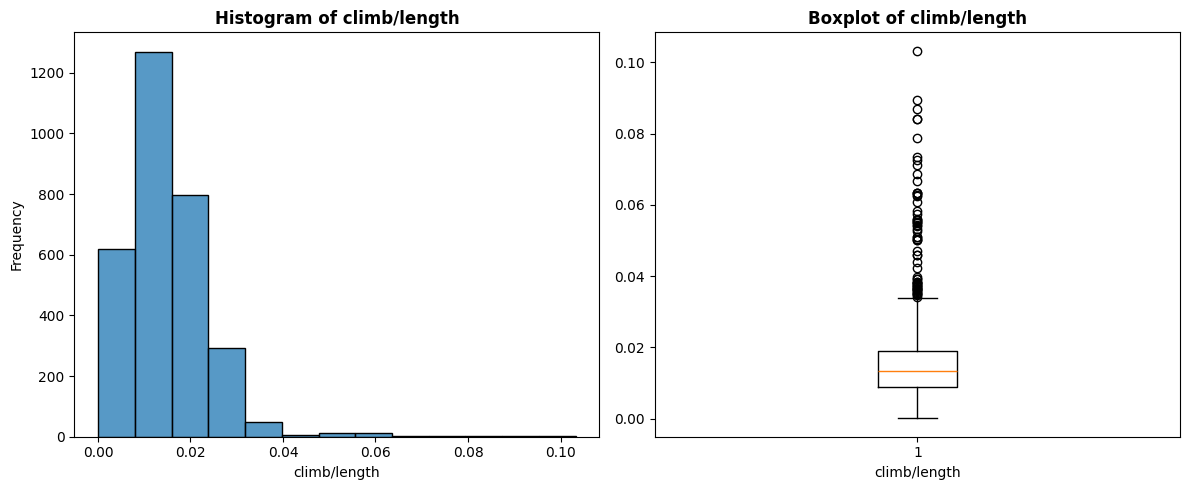

Outliers in climb/length: [0.0625, 0.05580808080808081, 0.03835294117647059, 0.06345833333333334, 0.07268518518518519, 0.05023648648648649, 0.03691275167785235, 0.05395833333333333, 0.05271844660194175, 0.05446575342465754, 0.035765217391304345, 0.0352415210688592, 0.056, 0.03459119496855346, 0.05322916666666667, 0.036375, 0.03806363636363636, 0.03423423423423423, 0.035515151515151513, 0.034926470588235295, 0.03725641025641026, 0.03976470588235294, 0.03772350230414746, 0.044, 0.05821875, 0.05023157894736842, 0.06075313807531381, 0.046052631578947366, 0.05101639344262295, 0.04709090909090909, 0.03624503311258278, 0.04594285714285714, 0.05489583333333333, 0.037445378151260506, 0.07126666666666667, 0.06674074074074074, 0.03928260869565217, 0.05514619883040936, 0.057526881720430106, 0.03906040268456376, 0.087, 0.042339181286549704, 0.034957627118644065, 0.036417910447761194, 0.05092783505154639, 0.036565371024734984, 0.03723684210526316, 0.036036036036036036, 0.06264925373134328, 0.0686875

In [67]:
stats_and_distribution(races, 'climb/length', attr_type='numerical')

We can observe that the distribution presents a positive skew with a long tail. This means that most of the races have small a climb/length ratio, in particular the climb part of a race event is typically <4%. The boxplot classifies as outliers all the races with a ratio grater than 2.85%. Notice that there is a single race event with an uphill portion of that constitutes 10% of the total distance.

In [68]:
iqr=(races['climb/length'].quantile(0.75))-(races['climb/length'].quantile(0.25))
print(f"Upper wisker limit: {races['climb/length'].quantile(0.5)+1.5*iqr}")

Upper wisker limit: 0.028501854042755605


In [69]:
races[races['climb/length']==0.10326086956521739]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length
1144,tour-de-france/1996/stage-9,Tour de France,100,<NA>,46000,4750,5,1872,<NA>,True,False,False,1996-07-08,0.103261


In [70]:
print(f"Correlation between climb/length and profile: {races['climb/length'].corr(races['profile'], method='kendall')}")
print(f"Correlation between climb and profile: {races['climb_total'].corr(races['profile'], method='kendall')}")
print(f"Correlation between length and profile: {races['length'].corr(races['profile'], method='kendall')}")

Correlation between climb/length and profile: 0.6251513605040532
Correlation between climb and profile: 0.572520132871134
Correlation between length and profile: 0.006155688405006674


As shown by the Kendall scores, which is the best metric for assessing correlation with a rank attribute, using the ratio climb/length has increased the correlation with the ordinal feature 'profile' compared to just looking at the 'climb_total' value.

## Median and std_dev of the delta

It might be interesting to determine the median and standard deviation of the delta values in each race, as we would expect some races with particular characteristics, such as the hilliness, to influence the deltas recorded in the cyclists' placings. <br> As already told in the 'placements' data undestanding notebook, the delta feature of the placements have some problems that we have properly corrected. For this reason we need to read the _preprocessedPlacements_ cvs file.

In [71]:
placements = pd.read_csv('../../dataset/preprocessedPlacements.csv', sep=",")

We derive two new features _median_\_delta_ and _std\_delta_, by calculating the mean and standard deviation of the _delta_ column for each _\_url_ group in placements and assigning these values to each row within the respective group.

In [72]:
placements['median_delta'] = placements.groupby('_url')['delta'].transform('median')
placements['std_delta'] = placements.groupby('_url')['delta'].transform('std')

We would like to add these features to the races dataframe, as they are general fields related to the race rather than to the individual placements. Before performing the inner join, we check the consistency of _urls.

In [73]:
if races['_url'].isin(placements['_url']).all():
    races = races.merge(
        placements.groupby('_url')['delta'].agg(median_delta='median', std_delta='std').reset_index(),
        on='_url', how='inner'
    )
    print("Inner join done: each rows in races has a match in placements")
else:
    print("Inner join issue: some rows in races doesn't match in placements")

Inner join done: each rows in races has a match in placements


In [74]:
placements[placements['_url'].isin(races[races['std_delta'].isna()]['_url'].to_list())]

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,year,median_delta,std_delta
54730,0,carlos-alberto-contreras,28,NaN,0,2001-06-02,giro-d-italia/2001/stage-14,2001,0.0,NaN
135751,0,eddy-merckx,27,ceramica-panaria-navigare-2007,0,1972-10-07,il-lombardia/1972/result,1972,0.0,NaN
416830,0,giancarlo-polidori,29,sport-vlaanderen-baloise-2021,0,1972-06-17,tour-de-suisse/1972/stage-2,1972,0.0,NaN
416831,0,giancarlo-polidori,29,sport-vlaanderen-baloise-2021,0,1972-06-21,tour-de-suisse/1972/stage-6b,1972,0.0,NaN
416832,0,wilfried-david,26,liberty-seguros-wurth-team-2005,0,1972-06-22,tour-de-suisse/1972/stage-7,1972,0.0,NaN
416833,0,gerben-karstens,30,denmark-1991,0,1972-06-23,tour-de-suisse/1972/stage-8a,1972,0.0,NaN


We notice that there are races for which the standard deviation of the respective placements is zero; this is because there's only one placement for that race. Since there is no variability in the placements of that races, we decide to correct this statistics with a zero value.

In [75]:
races['std_delta'] = races['std_delta'].fillna(0)

In [76]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'is_tarmac',
       'is_cobbled', 'is_gravel', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

Description of attribute 'median_delta':


count     5281.000000
mean       349.791327
std        971.200406
min          0.000000
25%          5.000000
50%        113.000000
75%        477.500000
max      46380.000000
Name: median_delta, dtype: float64


Unique values:
[  27.  1957.    29.  ...  924.5 2185.   197.5]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
0.0    1195
2.0      39
4.0      32
3.0      30
8.0      30
Name: median_delta, dtype: int64


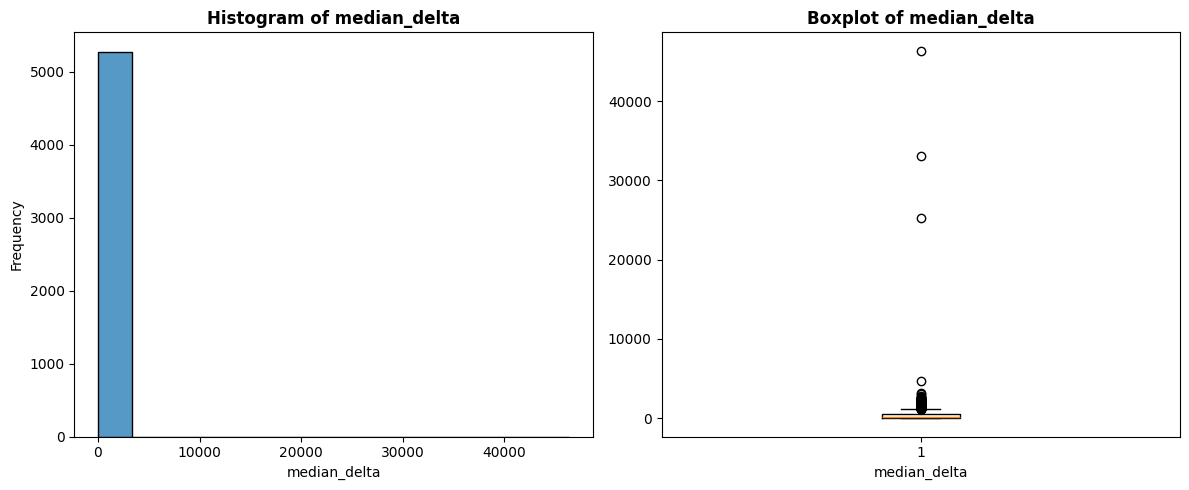

Outliers in median_delta: [2048.0, 2060.0, 2062.0, 2072.0, 2080.0, 2083.0, 2090.0, 2101.0, 2109.5, 2120.0, 2126.0, 2140.0, 2154.0, 2156.0, 2169.0, 2185.0, 2191.0, 2193.0, 2199.0, 2208.0, 2210.0, 2216.0, 2244.0, 2274.5, 2365.0, 2368.5, 2370.0, 2373.0, 2399.0, 2419.0, 33140.0, 2426.0, 2500.0, 2562.0, 2657.0, 25223.0, 4751.0, 2732.0, 2825.0, 3018.0, 3234.0, 1187.0, 1189.0, 1193.0, 1194.0, 1195.0, 1199.0, 1200.0, 1202.0, 1203.0, 1205.0, 1208.0, 1210.0, 1216.0, 1217.0, 1219.0, 1220.0, 1221.0, 1222.0, 1224.0, 1226.0, 1227.0, 1228.0, 1229.0, 1230.0, 1234.0, 1235.0, 1236.0, 1239.0, 1242.0, 1243.0, 1244.0, 1245.0, 1246.0, 1247.0, 1248.0, 1250.0, 1251.0, 1252.0, 1253.0, 1254.0, 1256.5, 1256.0, 1259.0, 1260.0, 1262.0, 1263.0, 1265.0, 1267.0, 1271.5, 1271.0, 1278.0, 1279.0, 1282.0, 1283.0, 1287.0, 1288.0, 1287.5, 1290.0, 1291.0, 1292.0, 1293.0, 1296.0, 1297.0, 1298.0, 1300.0, 1302.0, 1304.5, 1305.0, 1304.0, 1310.0, 1312.0, 1313.0, 1314.0, 1315.0, 1317.0, 46380.0, 1326.0, 1330.0, 1333.0, 1335.0, 13

In [77]:
stats_and_distribution(races, 'median_delta', attr_type='numerical')

Description of attribute 'median_delta':


count     5281.000000
mean       349.791327
std        971.200406
min          0.000000
25%          5.000000
50%        113.000000
75%        477.500000
max      46380.000000
Name: median_delta, dtype: float64


Unique values:
[  27.  1957.    29.  ...  924.5 2185.   197.5]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
0.0    1195
2.0      39
4.0      32
3.0      30
8.0      30
Name: median_delta, dtype: int64


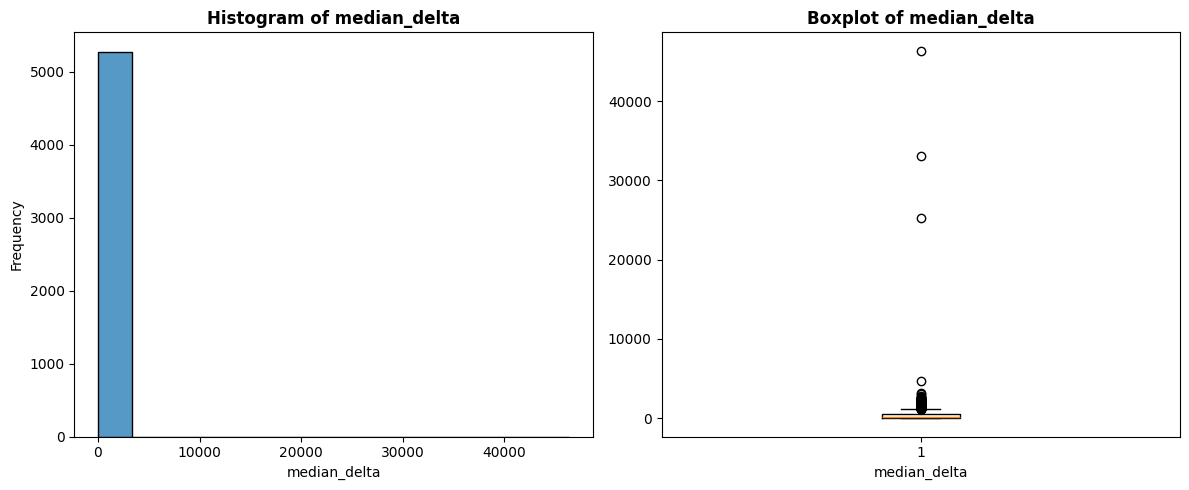

Outliers in median_delta: [2048.0, 2060.0, 2062.0, 2072.0, 2080.0, 2083.0, 2090.0, 2101.0, 2109.5, 2120.0, 2126.0, 2140.0, 2154.0, 2156.0, 2169.0, 2185.0, 2191.0, 2193.0, 2199.0, 2208.0, 2210.0, 2216.0, 2244.0, 2274.5, 2365.0, 2368.5, 2370.0, 2373.0, 2399.0, 2419.0, 33140.0, 2426.0, 2500.0, 2562.0, 2657.0, 25223.0, 4751.0, 2732.0, 2825.0, 3018.0, 3234.0, 1187.0, 1189.0, 1193.0, 1194.0, 1195.0, 1199.0, 1200.0, 1202.0, 1203.0, 1205.0, 1208.0, 1210.0, 1216.0, 1217.0, 1219.0, 1220.0, 1221.0, 1222.0, 1224.0, 1226.0, 1227.0, 1228.0, 1229.0, 1230.0, 1234.0, 1235.0, 1236.0, 1239.0, 1242.0, 1243.0, 1244.0, 1245.0, 1246.0, 1247.0, 1248.0, 1250.0, 1251.0, 1252.0, 1253.0, 1254.0, 1256.5, 1256.0, 1259.0, 1260.0, 1262.0, 1263.0, 1265.0, 1267.0, 1271.5, 1271.0, 1278.0, 1279.0, 1282.0, 1283.0, 1287.0, 1288.0, 1287.5, 1290.0, 1291.0, 1292.0, 1293.0, 1296.0, 1297.0, 1298.0, 1300.0, 1302.0, 1304.5, 1305.0, 1304.0, 1310.0, 1312.0, 1313.0, 1314.0, 1315.0, 1317.0, 46380.0, 1326.0, 1330.0, 1333.0, 1335.0, 13

In [78]:
stats_and_distribution(races, 'median_delta', attr_type='numerical')

## Number of participants

Let's create this new feature that contains the number of participants to each race event.

In [79]:
whole_dataset=pd.read_csv('../../dataset/races.csv')
counts = whole_dataset['_url'].value_counts().reset_index()
counts.columns = ['_url', '# participants']
races=races.merge(counts, on='_url', how='left')
races

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
0,tour-de-france/1978/stage-6,Tour de France,100,<NA>,162000,1101,1,1241,<NA>,True,False,False,1978-07-05,0.006796,27.0,6.847590,106
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100,196000,5575,5,821,<NA>,True,False,False,2016-09-03,0.028444,1957.0,873.835670,165
2,tour-de-france/2019/stage-21,Tour de France,100,120,128000,781,1,1699,<NA>,True,False,False,2019-07-28,0.006102,29.0,44.079531,155
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,<NA>,8100,<NA>,<NA>,804,<NA>,True,False,False,1999-06-17,<NA>,53.0,27.154498,119
4,tour-de-france/2022/stage-9,Tour de France,100,120,192900,3743,3,1551,24,True,False,False,2022-07-10,0.019404,1376.0,675.354230,164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,giro-d-italia/2017/stage-3,Giro d'Italia,80,100,148000,1441,1,881,<NA>,True,False,False,2017-05-07,0.009736,77.0,120.702086,195
5277,paris-roubaix/2000/result,Paris - Roubaix,275,<NA>,273000,<NA>,1,808,<NA>,False,False,False,2000-04-10,<NA>,270.0,327.665558,66
5278,paris-nice/1976/stage-2,Paris - Nice,50,<NA>,185000,<NA>,<NA>,779,<NA>,True,False,False,1976-03-09,<NA>,0.0,0.000000,79
5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50,50,136400,1880,2,1045,<NA>,True,False,False,2016-03-27,0.013783,209.0,176.293335,126


Description of attribute '# participants':


count    5281.000000
mean      111.695702
std        64.935049
min         1.000000
25%        42.000000
50%       137.000000
75%       164.000000
max       210.000000
Name: # participants, dtype: float64


Unique values:
[106 165 155 119 164 157  96 113   9  20  25   5 135  45 169 183 120 178
 149 166 114 152 112  63 153  10  79 175 159 154  15 109 139 191 170 148
 188 128  17 133 194 181 110 160 158 161 174 167  98  71 196 163 182  44
 147 156 116 198 124 126 184 150  77   6  49 185 104   7 108 168 189  90
  97 151 123  54  81 138  41  70  30 140 180  33 122 143  14 127  92 125
 173  76  72  21 187  40 141 144   4  51 118 136  34 206  85 192  86 145
  74 107 121  78 146  75 186  99 179 103 190 105 171 195  11 130  95  73
  83  80 137  26  23  13  61  19 142  91 132  60   8  62 111  65 115 131
  82   3  43 101 129 162 176  87 172 177  48 134  12 193  46  58  27 102
  52  88  50 197  39 100 117  89  31  55   1  94  84  47  66 199  16  93
  29  53  56  36 202  24 201  42 204  69  28  59   2  18  64 205 203  37
 210  22  35  57  67  32  68  38 207]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
10     443
6      151
5      120
20     105
164     78
Name: # partici

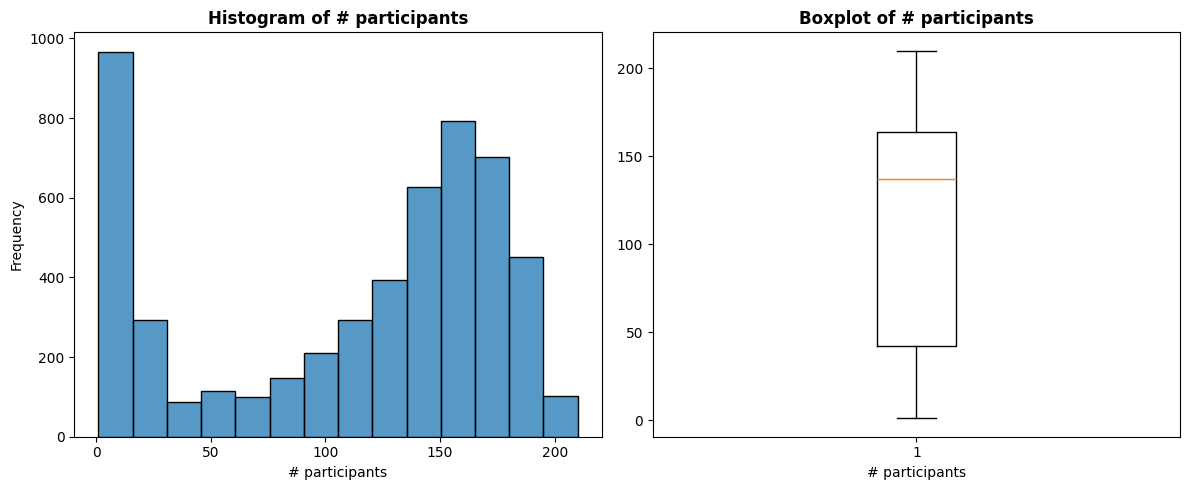

Outliers in # participants: []


In [80]:
stats_and_distribution(races, '# participants', attr_type='numerical')

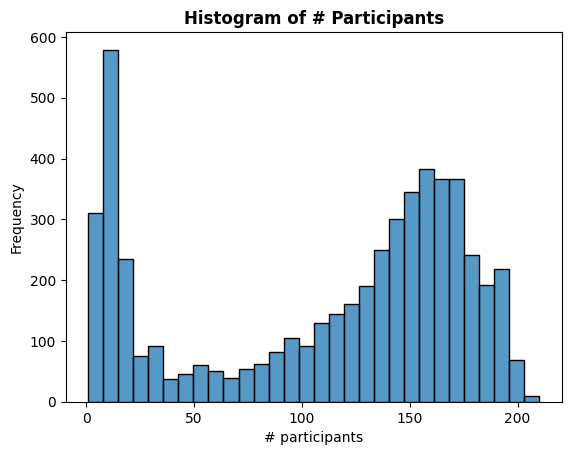

In [81]:
sbn.histplot(races['# participants'], bins=30)
plt.title('Histogram of # Participants', fontweight='bold')
plt.xlabel('# participants')
plt.ylabel('Frequency')
plt.show()

The distribution shows two peaks, one describing an high number of races with a limited number of participants and another referring to races with quite high cyclists (around 150). From the statistics we can observe that 25% of the races have less than 42 participants and there commonest value is '10' which is repeated for 43 events. The average value of participants is 111.

We imagine that this feature will be correlated with 'startlist_quality', as we expect races with many participants to have a higher quality value (note that this depends on the quality of the cyclists, but the more participants there are, the more likely it is to have valuable cyclists).

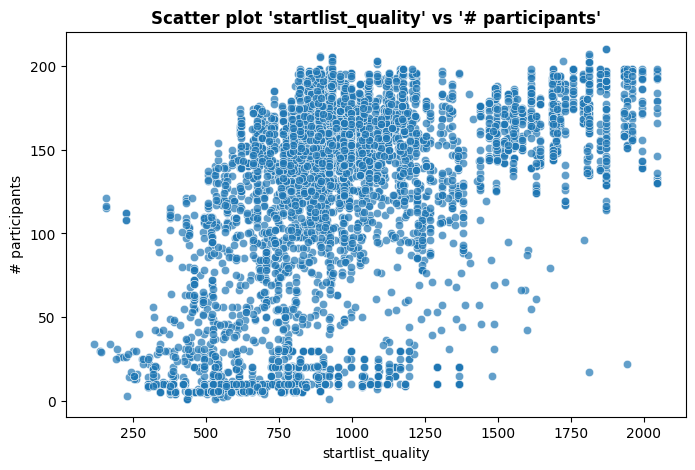

In [82]:
plt.figure(figsize=(8, 5))
sbn.scatterplot(x=races["startlist_quality"], y=races["# participants"], alpha=0.7)
plt.title("Scatter plot 'startlist_quality' vs '# participants'", fontweight='bold')
plt.xlabel("startlist_quality")
plt.ylabel("# participants")
plt.show()
plt.close()

The plot confirms our intution, even if there is not a strong linear realtionship between these features.

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\1089097787.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  pearson_matrix = races[numeric_columns].corr(method = "pearson")


,points,uci_points,startlist_quality,length,climb_total,average_temperature,# participants,median_delta,std_delta,climb/length
points,1.000000,0.886923,0.150258,0.443933,0.148629,-0.145383,-0.006839,0.035309,0.051208,-0.058704
uci_points,0.886923,1.000000,-0.027519,0.308246,0.112018,-0.207581,-0.396950,-0.009955,-0.015675,-0.057068
startlist_quality,0.150258,-0.027519,1.000000,0.075864,0.040131,0.352969,0.508554,0.096597,0.069962,0.012301
length,0.443933,0.308246,0.075864,1.000000,0.530568,-0.078542,0.027636,0.075307,0.117848,-0.181041
climb_total,0.148629,0.112018,0.040131,0.530568,1.000000,-0.133245,-0.100610,0.320819,0.283857,0.550005
average_temperature,-0.145383,-0.207581,0.352969,-0.078542,-0.133245,1.000000,0.110934,0.065262,0.007340,-0.089716
# participants,-0.006839,-0.396950,0.508554,0.027636,-0.100610,0.110934,1.000000,0.150158,0.192346,-0.094925
median_delta,0.035309,-0.009955,0.096597,0.075307,0.320819,0.065262,0.150158,1.000000,0.793629,0.238042
std_delta,0.051208,-0.015675,0.069962,0.117848,0.283857,0.007340,0.192346,0.793629,1.000000,0.178994
climb/length,-0.058704,-0.057068,0.012301,-0.181041,0.550005,-0.089716,-0.094925,0.238042,0.178994,1.000000


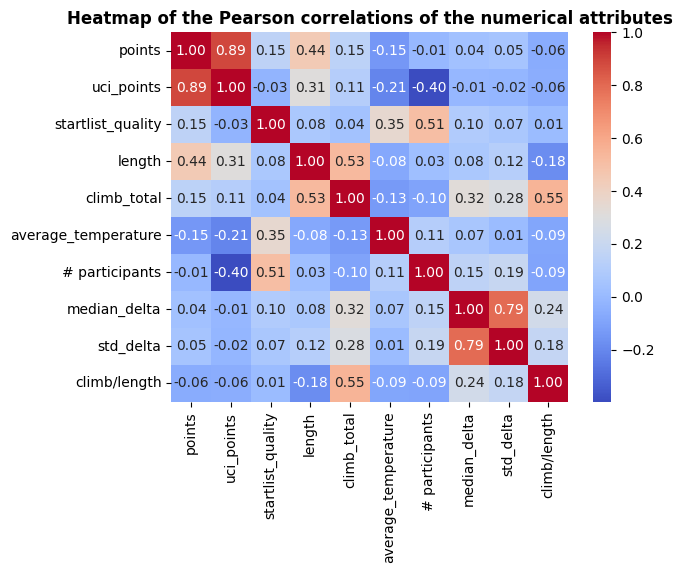

In [83]:
numeric_columns = ['points', 'uci_points', 'startlist_quality', 
                   'length', 'climb_total', 'average_temperature', 'date', 
                   '# participants', 'median_delta', 'std_delta', 'climb/length']
pearson_matrix = races[numeric_columns].corr(method = "pearson")
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of the Pearson correlations of the numerical attributes", fontweight='bold')
plt.show()
plt.close()

As expected, there is a strong correlation between 'median_delta' and 'std_delta', as we expect races with a high median delta to have more variability in the delta values of the individual cyclists. We also note a Pearson correlation value of 0.51 between '# participants' and 'startlist_quality', which is not so high but still significant. These values confirm our intuitions explained earlier.  We can also see that there is a correlation of -0.4 between 'uci_points' and '# participants', but the 'uci_points' column is dropped due to critical data quality issues.

# Imputation

In [84]:
def imputationComparison(original_df, imputed_df, column):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation', fontweight='bold')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    plt.close()

Let's save a copy of the dataframe before the imputation to make the check on the impact of the imputation strategies adopted.

In [85]:
races_pre_imputation=races.copy()

## Points

In [86]:
races[races['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,<NA>,<NA>,166900,1547,<NA>,791,<NA>,True,False,False,1994-04-29,0.009269,0.0,52.433724,165
4167,tour-de-france/1986/stage-19,Tour de France,<NA>,<NA>,179500,3000,4,1872,<NA>,True,False,False,1986-07-23,0.016713,450.0,277.761222,135
4661,tour-de-france/1988/prologue,Tour de France,<NA>,<NA>,1000,44,1,1941,<NA>,True,False,False,1988-07-03,0.044,6.5,4.428362,22
5035,tour-de-france/2019/stage-19,Tour de France,<NA>,<NA>,89000,2995,5,1699,<NA>,True,False,False,2019-07-26,0.033652,1020.0,538.845328,155


As we can see there are only 4 race events for which we have not the point reference. Let's see again which 'points' are typically assigned to a race; we expect them to be to assume values in a defined set/range.

In [87]:
points_set=np.sort(races['points'].dropna(inplace=False).unique())
points_set

array([18, 20, 30, 35, 50, 70, 75, 80, 100, 125, 150, 225, 275, 350],
      dtype=object)

In [88]:
tdf_no_points=races[races['_url'].str.contains(r'tour-de-france/\d{4}/stage-19', regex=True)].sort_values(by="_url")
tdf_no_points

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
230,tour-de-france/1978/stage-19,Tour de France,100,<NA>,182000,2000,2,1241,<NA>,True,False,False,1978-07-20,0.010989,31.0,10.593352,78
334,tour-de-france/1979/stage-19,Tour de France,100,<NA>,162000,1568,2,1381,<NA>,True,False,False,1979-07-17,0.009679,0.0,0.000000,91
1927,tour-de-france/1980/stage-19,Tour de France,100,<NA>,136500,2439,4,1224,<NA>,True,False,False,1980-07-17,0.017868,20.0,283.296139,86
971,tour-de-france/1981/stage-19,Tour de France,100,<NA>,117500,1996,2,1362,<NA>,True,False,False,1981-07-16,0.016987,229.0,168.236918,123
5055,tour-de-france/1982/stage-19,Tour de France,100,<NA>,48000,508,2,1492,<NA>,True,False,False,1982-07-23,0.010583,388.5,183.533819,126
1310,tour-de-france/1983/stage-19,Tour de France,100,<NA>,15000,1069,5,1269,<NA>,True,False,False,1983-07-21,0.071267,248.0,114.088009,89
913,tour-de-france/1984/stage-19,Tour de France,100,<NA>,186000,5500,4,1632,<NA>,True,False,False,1984-07-18,0.02957,718.0,512.667779,127
3530,tour-de-france/1985/stage-19,Tour de France,100,<NA>,200000,1637,1,1470,<NA>,True,False,False,1985-07-18,0.008185,18.0,7.108977,145
4167,tour-de-france/1986/stage-19,Tour de France,<NA>,<NA>,179500,3000,4,1872,<NA>,True,False,False,1986-07-23,0.016713,450.0,277.761222,135
1770,tour-de-france/1987/stage-19,Tour de France,100,<NA>,185000,4842,4,1812,<NA>,True,False,False,1987-07-20,0.026173,916.0,578.006727,152


In [89]:
tour_de_france_df = races[races['_url'].str.startswith('tour-de-france')]
tour_de_france_df['points'].value_counts(normalize=True)

100    0.975771
70     0.023128
50     0.001101
Name: points, dtype: Float64

We can observe that 97% of the stages of the "Tour de France" have a score of 100. Since the scores are "drawn" from a specific set, as already told before, it's reasonable to assign the score 100 to the 3 stages of the "Tour de France" with a NaN reference.

In [90]:
rows_to_fill = races[(races['_url'].str.startswith('tour-de-france'))&(races['points'].isna())]
rows_to_fill

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
4167,tour-de-france/1986/stage-19,Tour de France,<NA>,<NA>,179500,3000,4,1872,<NA>,True,False,False,1986-07-23,0.016713,450.0,277.761222,135
4661,tour-de-france/1988/prologue,Tour de France,<NA>,<NA>,1000,44,1,1941,<NA>,True,False,False,1988-07-03,0.044,6.5,4.428362,22
5035,tour-de-france/2019/stage-19,Tour de France,<NA>,<NA>,89000,2995,5,1699,<NA>,True,False,False,2019-07-26,0.033652,1020.0,538.845328,155


In [91]:
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(100)
races.update(rows_to_fill) #update the dataframe which still have NaNs

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\2313637028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(100)
C:\Users\simon\AppData\Local\Temp\ipykernel_10928\2313637028.py:1: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(100)


In [92]:
races[races['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,<NA>,<NA>,166900,1547,<NA>,791.0,<NA>,True,False,False,1994-04-29,0.009269,0.0,52.433724,165.0


In [93]:
vae_no_points=races[races['_url'].str.startswith('vuelta-a-espana')]
vae_no_points['points'].value_counts(normalize=True)

80    0.996641
50    0.003359
Name: points, dtype: float64

Since 99% of the race events related to '_vuelta-a-espana_' have a score of 80, we decide to impute the only stage with a NaN using this value.

In [94]:
rows_to_fill = races[(races['_url'].str.startswith('vuelta-a-espana'))&(races['points'].isna())]
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(80)
races.update(rows_to_fill) #update the dataframe which still have NaNs

C:\Users\simon\AppData\Local\Temp\ipykernel_10928\600888533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(80)
C:\Users\simon\AppData\Local\Temp\ipykernel_10928\600888533.py:2: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(80)


In [95]:
races[races['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants


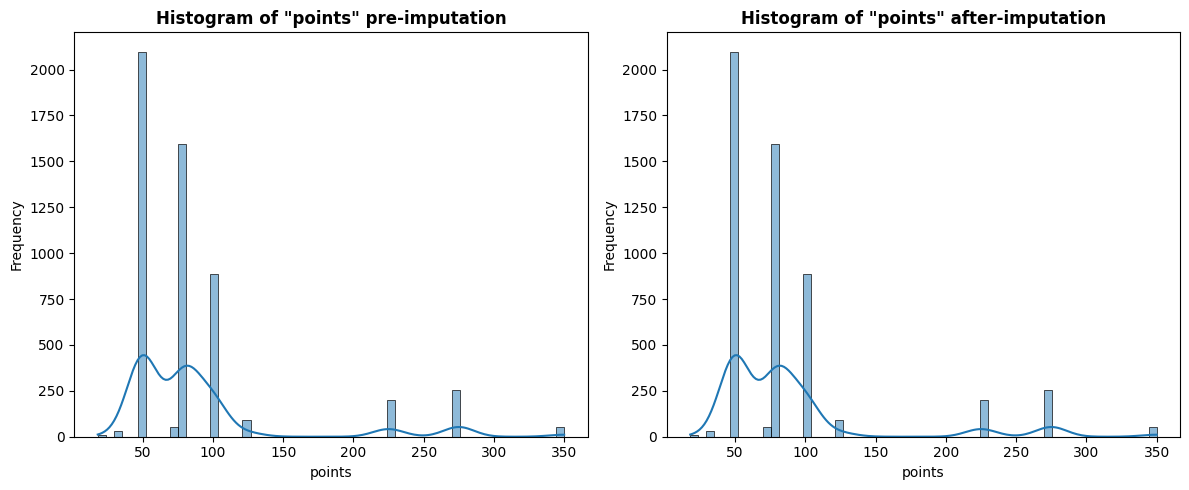

In [96]:
imputationComparison(races_pre_imputation, races_data, 'points')

Since we have operated on few races, we have not significantly influenced the distribution of that feature.

## Climb_total

In [97]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'is_tarmac',
       'is_cobbled', 'is_gravel', 'date', 'climb/length', 'median_delta',
       'std_delta', '# participants'],
      dtype='object')

In [98]:
races

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta,# participants
0,tour-de-france/1978/stage-6,Tour de France,100,<NA>,162000,1101,1,1241.0,<NA>,True,False,False,1978-07-05,0.006796,27.0,6.847590,106.0
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100,196000,5575,5,821.0,<NA>,True,False,False,2016-09-03,0.028444,1957.0,873.835670,165.0
2,tour-de-france/2019/stage-21,Tour de France,100,120,128000,781,1,1699.0,<NA>,True,False,False,2019-07-28,0.006102,29.0,44.079531,155.0
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,<NA>,8100,<NA>,<NA>,804.0,<NA>,True,False,False,1999-06-17,<NA>,53.0,27.154498,119.0
4,tour-de-france/2022/stage-9,Tour de France,100,120,192900,3743,3,1551.0,24,True,False,False,2022-07-10,0.019404,1376.0,675.354230,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,giro-d-italia/2017/stage-3,Giro d'Italia,80,100,148000,1441,1,881.0,<NA>,True,False,False,2017-05-07,0.009736,77.0,120.702086,195.0
5277,paris-roubaix/2000/result,Paris - Roubaix,275,<NA>,273000,<NA>,1,808.0,<NA>,False,False,False,2000-04-10,<NA>,270.0,327.665558,66.0
5278,paris-nice/1976/stage-2,Paris - Nice,50,<NA>,185000,<NA>,<NA>,779.0,<NA>,True,False,False,1976-03-09,<NA>,0.0,0.000000,79.0
5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50,50,136400,1880,2,1045.0,<NA>,True,False,False,2016-03-27,0.013783,209.0,176.293335,126.0


In [100]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total            2214
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length           2214
median_delta              0
std_delta                 0
dtype: int64

In [101]:
races.shape[0]

5281

In [102]:
no_climb_total_urls=races[races['climb_total'].isna()]['_url'].tolist()
len(no_climb_total_urls)

2214

In [103]:
races_pre_imputation=races.copy()

### Standardization
We standardize selected numeric features in the _races\_date_ dataframe. We do not consider columns with many NaNs, high correlation, or non-numeric values. The selected features are scaled to have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#no 'uci_points' because there are a lot of NaNs and it is highly correlated to points
#no  '# participants' because is correlated to startlist_quality
#no 'average_temperature' because 96% of the values are NaNs
#no 'profile' because it's an ordinal feature
#no 'climb/lenght' because it's an artificial column that is not used here
numeric_columns=['points', 'length', 'climb_total', 'startlist_quality', 'median_delta', 'std_delta']
numeric_races=races[numeric_columns]
scaler.fit(numeric_races)
X = scaler.transform(numeric_races)

In [102]:
X

array([[ 0.1715365 , -0.05429348, -0.91427639,  0.66321901, -0.33239473,
        -0.43541137],
       [-0.15426841,  0.44656511,  2.29481713, -0.44083854,  1.65502491,
         1.25321216],
       [ 0.1715365 , -0.55515206, -1.14380476,  1.86716747, -0.33033522,
        -0.36289512],
       ...,
       [-0.64297576,  0.28452262,         nan, -0.55124429, -0.36019801,
        -0.44874835],
       [-0.64297576, -0.43141053, -0.35551827,  0.14799215, -0.14498003,
        -0.10538368],
       [-0.15426841, -2.31699579, -1.66096087, -0.29100216, -0.31591871,
        -0.41239679]])

Creation of a dataframe from those standardized data

In [103]:
standardized_races = pd.DataFrame(X, columns=numeric_columns)
standardized_races

,points,length,climb_total,startlist_quality,median_delta,std_delta
0,0.171536,-0.054293,-0.914276,0.663219,-0.332395,-0.435411
1,-0.154268,0.446565,2.294817,-0.440839,1.655025,1.253212
2,0.171536,-0.555152,-1.143805,1.867167,-0.330335,-0.362895
3,-0.642976,-2.321415,NaN,-0.485527,-0.305621,-0.395860
4,0.171536,0.400899,0.980767,1.478119,1.056740,0.866632
...,...,...,...,...,...,...
5276,-0.154268,-0.260529,-0.670402,-0.283116,-0.280907,-0.213658
5277,3.022329,1.580862,NaN,-0.475012,-0.082165,0.189442
5278,-0.642976,0.284523,NaN,-0.551244,-0.360198,-0.448748
5279,-0.642976,-0.431411,-0.355518,0.147992,-0.144980,-0.105384


In [104]:
def distributionComparison_for_KNN(original_df, imputed_df, column, k):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation with k={k}', fontweight='bold')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()  

### KNN imputation
We evaluate KNN imputation for missing values by testing different values of k (from 1 to 6). For each k, the missing data is imputed using KNN with distance-based weighting. The distribution of the imputed data for the _climb\_total_ column is compared with the pre-imputation distribution.

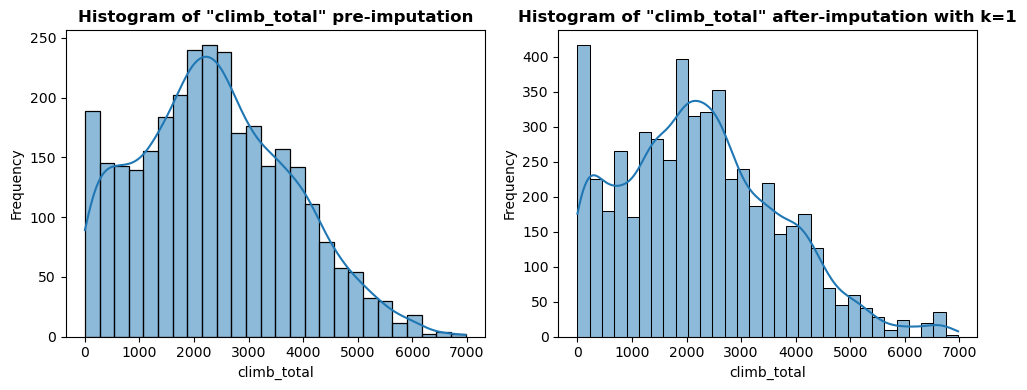

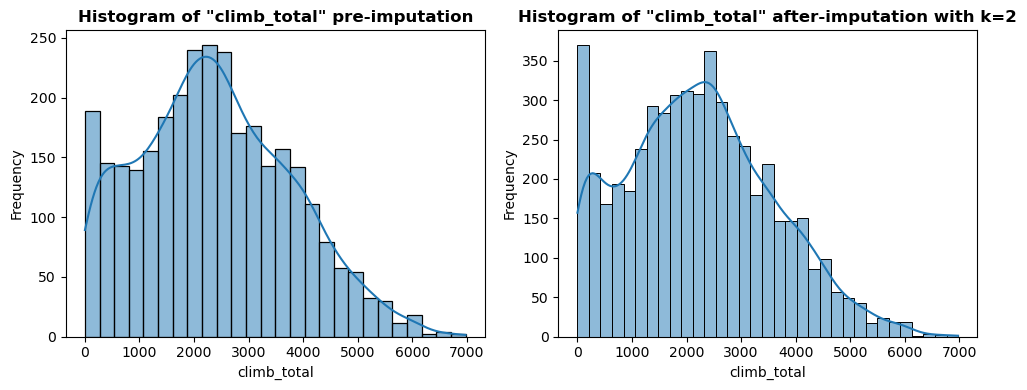

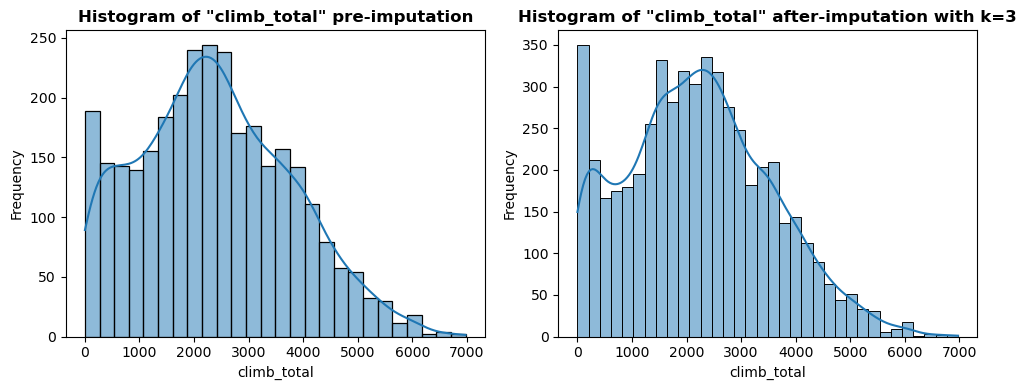

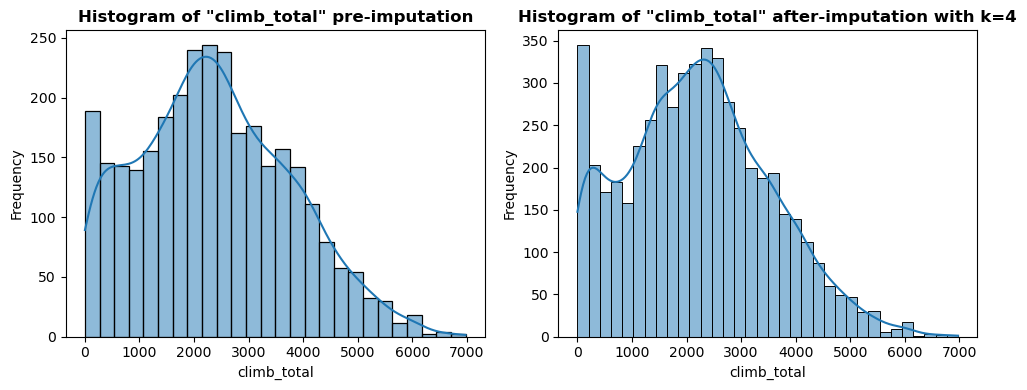

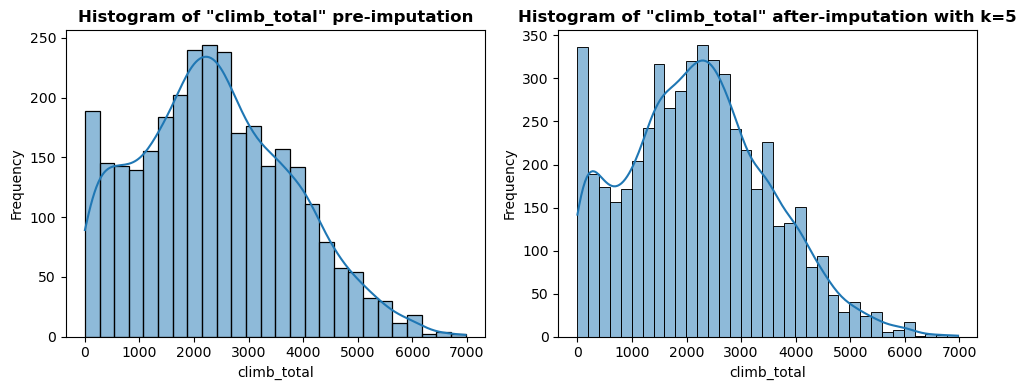

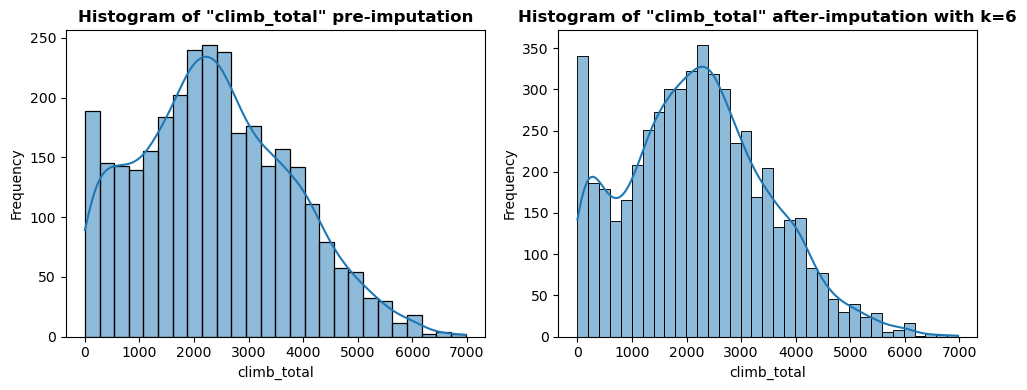

In [105]:
from sklearn.impute import KNNImputer

#range of k to evaluate imputation 
k_values = range(1, 7)  

for idx, k in enumerate(k_values, start=1):
    imputer = KNNImputer(n_neighbors=k, weights="distance")
    imputed_data = imputer.fit_transform(standardized_races)
    
    #Get back to the de-normalized representation
    df_imputed=pd.DataFrame(scaler.inverse_transform(imputed_data), columns=numeric_columns)

    races['climb_total']=df_imputed['climb_total']
    distributionComparison_for_KNN(races_pre_imputation, races, 'climb_total', k)

Based on the distributions obtained after imputation, the one that deviates the least from the original distribution is obtained with k=4, so we choose this value for imputation.

In [106]:
imputer = KNNImputer(n_neighbors=4, weights="distance")
imputed_data = imputer.fit_transform(standardized_races)
    
# Get back to the de-normalized representation
df_imputed=pd.DataFrame(scaler.inverse_transform(imputed_data), columns=numeric_columns)
races['climb_total']=df_imputed['climb_total'].round()

# Do again the column cast to Int64
cast_column_to_Int64(races, 'climb_total')

Column casted from float64 to Int64


Since we have imputed the climb total feature, let's recompute the 'climb/lenght' ratio also for those rows that previously had a NaN value for climb_total.

In [107]:
races['climb/length'] = races['climb_total'] / races['length']

## Profile

In [110]:
from distribution_utility import stats_and_distribution

Description of attribute 'profile':


count     2873
unique       5
top          2
freq       867
Name: profile, dtype: int64


Unique values:
[1 5 <NA> 3 2 4]

Null values: 2408 over 5281 records - (45.60%)

Top 5 most frequent values:
profile
2    867
1    817
5    575
3    327
4    287
Name: count, dtype: int64


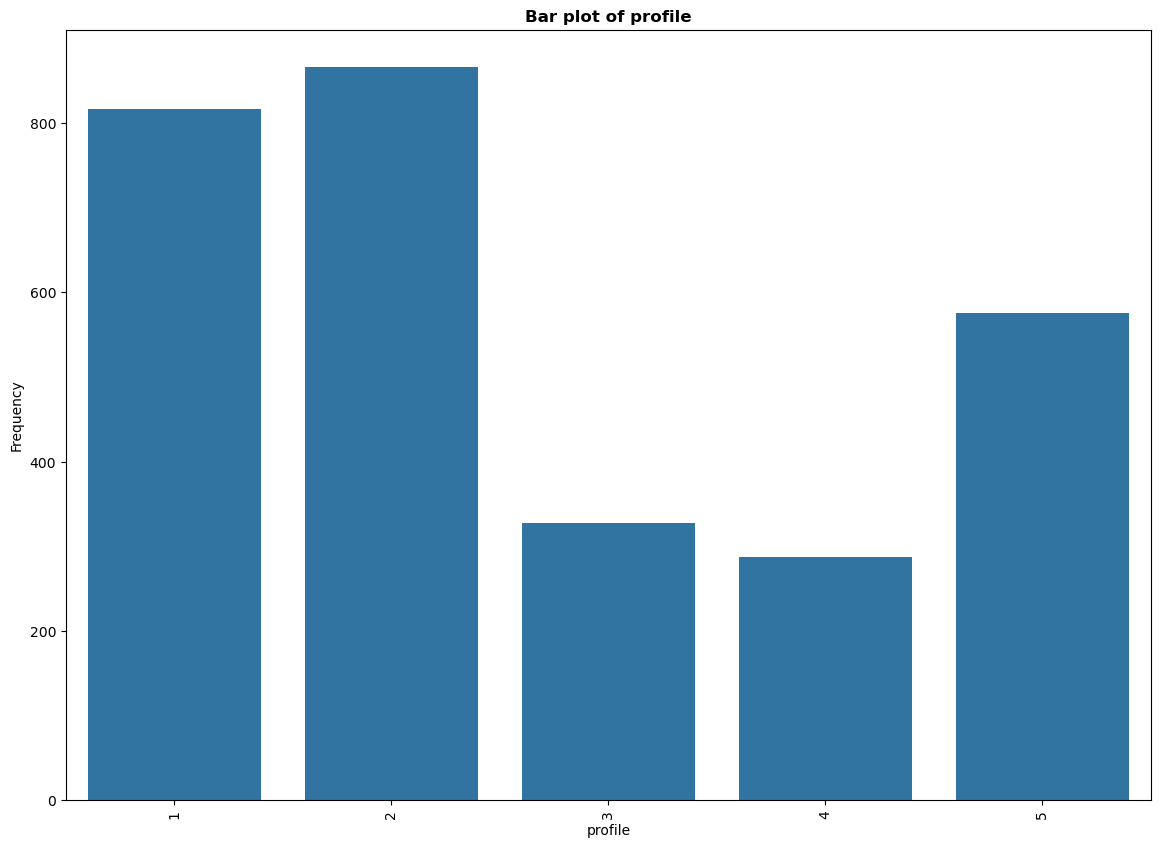

In [111]:
stats_and_distribution(races, 'profile', 'categorical')

In [112]:
races['climb/length'].isna().any()

False

Since the race profile describes its difficulty in terms of the number of climbs compared to the total length of the race, it makes sense to impute these NaN values taking into account the climb/length ratio. As the imputation of the total climb has already been done, we can use this information to reconstruct the profile as well.

In [114]:
filtered_races = races[races['profile'].notna()]
stats_table = filtered_races.groupby('profile')['climb/length'].describe().transpose()
print(stats_table)

profile         1         2         3         4         5
count       817.0     867.0     327.0     287.0     575.0
mean     0.008081  0.012952  0.014262  0.019497  0.024847
std      0.004718  0.004319  0.004411  0.005109   0.01107
min      0.000069  0.001265  0.005415  0.003159  0.001901
25%      0.005191  0.009786  0.011479  0.015868  0.019022
50%      0.007845  0.012626  0.014025  0.019005  0.022934
75%      0.010229  0.015676  0.016459  0.023461  0.027391
max         0.044  0.046053  0.036418  0.032583  0.103261


The imputation of the profile feature will be guided by the ratio _climb/length_, since it has a greater Kendall correlation score than the feature 'climb_total'. This result is reported in the notebook section where we have defined this novel feature. <br>
The statistics reported above show that is difficult to define ranges for the ratio in order to assign the proper 'profile' label, since there is an overlap for some profiles. For this reason the imputation is done by selecting the profile which has the nearest mean to our current climb/length ratio.

In [115]:
races_preImputation=races.copy()

In [116]:
#determine the mean climb/length ratio for each profile
profile_means = races.groupby('profile')['climb/length'].mean()
print("Mean climb/length ratio per profile\n",profile_means)

def impute_profile_by_mean(climb_length):
    # returns the index of the profile with the lowest distance with its mean value for the ratio
    return profile_means.sub(climb_length).abs().idxmin()

#imputation
races['profile'] = races['profile'].fillna(races['climb/length'].apply(impute_profile_by_mean))

Mean climb/length ratio per profile
 profile
1    0.008081
2    0.012952
3    0.014262
4    0.019497
5    0.024847
Name: climb/length, dtype: Float64


Description of attribute 'profile':


count     5281
unique       5
top          1
freq      1757
Name: profile, dtype: int64


Unique values:
[1 5 3 2 4]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
profile
1    1757
2    1355
3     845
5     742
4     582
Name: count, dtype: int64


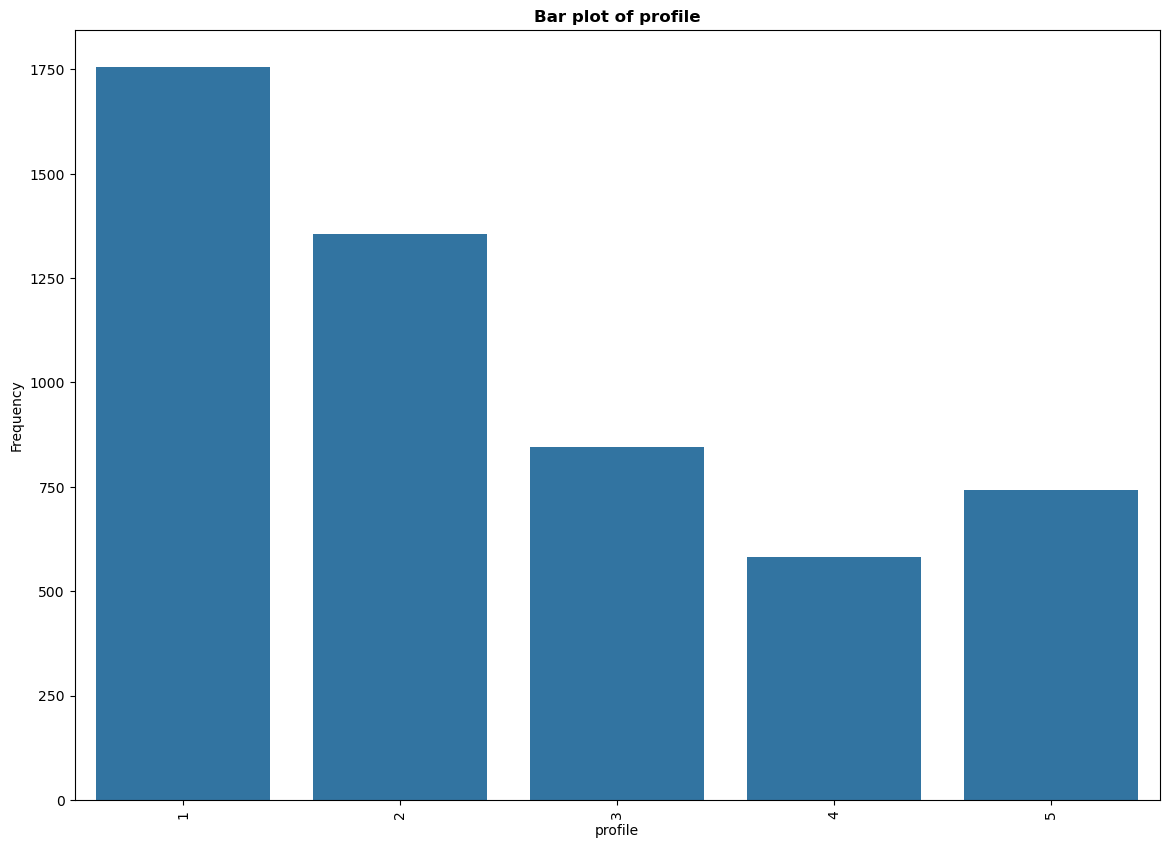

In [117]:
stats_and_distribution(races, 'profile', 'categorical')

The imputation has assigned the profile 1 to many races, in fact before the imputation the most populated profile was 2. This variation in the distribution, in some sense, cannot be avoidable since perhaps most of the races with a NaN profile have a small climb total value. Since about 42% of the races have a missing climb total information, its imputation strategy using the KNN may have influenced also the imputation of that profile.

In [118]:
import matplotlib.pyplot as plt
import seaborn as sbn

def show_side_by_side_bar_plots(df1, df2, column_name):
    values1 = df1[column_name].dropna()
    values_count1 = values1.value_counts().sort_index()
    percentages1 = (values_count1 / len(values1)) * 100

    values2 = df2[column_name].dropna()
    values_count2 = values2.value_counts().sort_index()
    percentages2 = (values_count2 / len(values2)) * 100

    # Coherent palette for each graph
    unique_values = sorted(set(values1.unique()).union(set(values2.unique())))
    colors = sbn.color_palette("Set2", len(unique_values))  # A color for each unique value
    color_map = {val: colors[i] for i, val in enumerate(unique_values)} 

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # First barplot (pre-imputation)
    sbn.barplot(
        x=values_count1.index, 
        y=values_count1.values, 
        ax=axes[0], 
        palette=[color_map[val] for val in values_count1.index]
    )
    axes[0].set_title(f'Bar plot of {column_name} pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count1.values, percentages1)):
        axes[0].text(i, v + max(values_count1.values) * 0.02, f'{perc:.1f}%', ha='center')

    # Second barplot (after imputation)
    sbn.barplot(
        x=values_count2.index, 
        y=values_count2.values, 
        ax=axes[1], 
        palette=[color_map[val] for val in values_count2.index]
    )
    axes[1].set_title(f'Bar plot of {column_name} after imputation', fontweight='bold')
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count2.values, percentages2)):
        axes[1].text(i, v + max(values_count2.values) * 0.02, f'{perc:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()

C:\Users\simon\AppData\Local\Temp\ipykernel_4368\3103321902.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(
C:\Users\simon\AppData\Local\Temp\ipykernel_4368\3103321902.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(


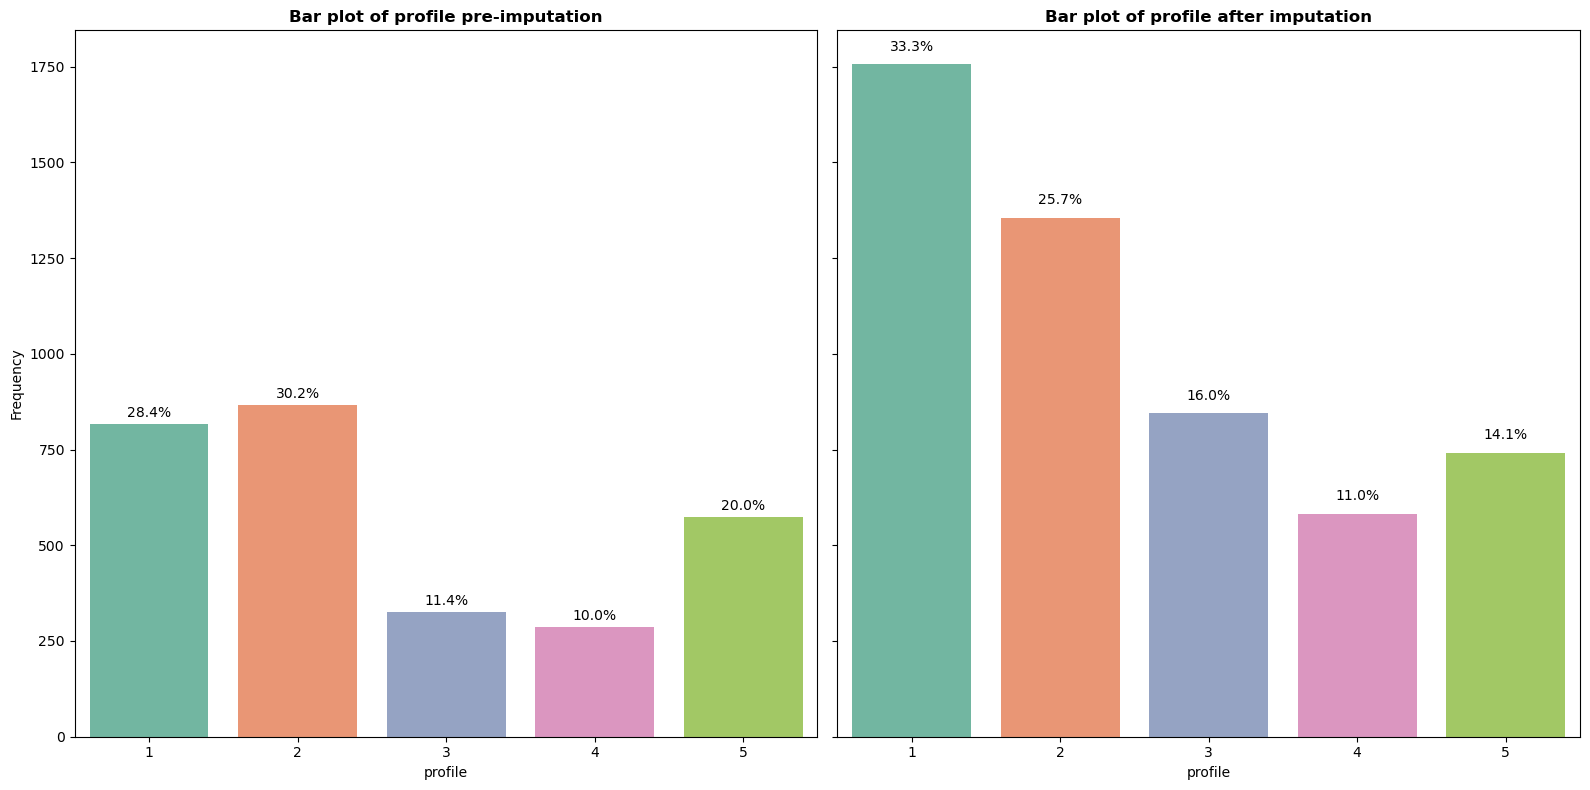

In [119]:
show_side_by_side_bar_plots(races_preImputation,races, 'profile')

# Generation of a new CSV
We generate a new CSV in which we have applied all the imputation/corrections to the data coming from the original dataset.

In [120]:
#races.to_csv('../../dataset/preprocessedRaces.csv', index=False)